# Comunidad energética EMS Excedentes FV Esparragosa de Lares:

## Importar

In [189]:
import pyomo.environ as pyo
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## Lectura de datos

In [190]:
# Lectura datos del mix energético seleccionado de 7 consumidores (ya en kW)

archivos_demanda = {
    "C2": "data/Commercial-450-bed Hospital.csv",
    "C8": "data/Commercial-Supermarket.csv",
    "C9": "data/Commercial-Wastewater Treatment Plant.csv",
    "C11": "data/Industrial-2-shift Fabricated Metals.csv",
    "C15": "data/Industrial-Plastic Manufacturer.csv",
    "C19": "data/Reference-Hotel.csv",
    "C21": "data/Reference-Residental.csv"
}

# Lectura de datos de generación solar de PVGis (W) para Esparragosa de Lares

archivos_solar = {
    "Esparragosa": "data/PRODUCCION SOLAR ESPARRAGOSA.csv"
}
 
# lectura de datos del precio de mercado de la energía en España peninsular (Pool 2023 €/MWh)

archivos_precios = {
    "Precio_Esp": "data/GUI_ENERGY_PRICES_ESPAÑA_PENINSULA2023.csv"
}

## Limpieza y procesamiento de datos

In [191]:
# funciones para lectura y procesado

def leer_demanda_consumidor(archivo):
    """Lee el consumo del cliente (en kW) y genera su estampa temporal directamente en UTC"""
    # Leemos el archivo saltando la primera fila de texto
    df = pd.read_csv(archivo, header=0)
    df.columns = ['demanda_kw'] # Nos aseguramos de que la columna se llame así
    
    # Como el CSV no trae fechas, generamos las 8760 horas del año 2023 en UTC
    df['datetime'] = pd.date_range(
        start="2023-01-01 00:00:00",
        periods=len(df), 
        freq='h', 
        tz='UTC')
    
    return df[['datetime', 'demanda_kw']]

def leer_generacion_pvgis(archivo):
    """Lee PVGis, salta cabecera y convierte W a kW"""
    # Saltamos las 11 filas de metadatos de PVGis
    df = pd.read_csv(archivo, skiprows=10, nrows=8760)
    
    # Esto es vital para que coincida con el precio y la demanda
    df['datetime'] = (pd.to_datetime(df['time'], format='%Y%m%d:%H%M')
                      .dt.floor('h') # Normalizamos el tiempo 20230101:0010 a la hora en punto (00:00)
                      .dt.tz_localize('UTC')) # Marcamos que estos datos son UTC
    
    # Dividimos por 1.000 para pasar de W a kW.
    # El archivo de PVGis ya viene para 1 kWp, así que no hace falta dividir por otros 1.000 adicionales.
    df['p_solar_kw'] = df['P'] / 10**3
    
    return df[['datetime', 'p_solar_kw']]

    
def leer_precio_mayorista(archivo):
    """Lee el Pool (Precio Mayorista), convierte EUR/MWh a EUR/kWh y lo convierte a UTC"""
    df = pd.read_csv(archivo)
    
    # Antes de convertir el tiempo, nos quedamos con el inicio de la hora
    # El split separa "01/01/2023 00:00:00 - 01/01/2023 01:00:00" y coge la primera parte en una temporal
    temp_dt = df['MTU (CET/CEST)'].str.split(' - ').str[0]

    # Limpieza clave, quitamos "(CET)" o "(CEST)" si aparecen en el texto (cambios de hora) para que no de error luego
    temp_dt = (
        temp_dt.str.replace(' (CET)', '', regex=False)
            .str.replace(' (CEST)', '', regex=False)
    )

    # Ahora que está limpio, convertimos a datetime y Lo mueve a UTC para que coincida con solar y demanda
    df['datetime'] = (pd.to_datetime(temp_dt, dayfirst=True)
                      .dt.tz_localize('CET', ambiguous='infer') # Identifica cuál de las dos horas de octubre es la repetida
                      .dt.tz_convert('UTC'))
    
    # Cambio de unidad: EUR/MWh -> EUR/kWh (Dividimos por 1000)
    df['pool_eur_kwh'] = df['Day-ahead Price (EUR/MWh)'] / 1000
    
    return df[['datetime', 'pool_eur_kwh']]



# suma de las demandas de los consumidores

df_demanda_total = None

for nombre, ruta in archivos_demanda.items():
    df_aux = leer_demanda_consumidor(ruta)
    
    if df_demanda_total is None:
        # Inicializamos con el datetime y la primera columna con su ID (ej: C2)
        df_demanda_total = df_aux.rename(columns={'demanda_kw': nombre})
    else:
        # Añadimos la columna del nuevo consumidor al dataframe existente
        df_demanda_total[nombre] = df_aux['demanda_kw'].values

# Una vez que tenemos todas las columnas individuales, creamos la suma total
# que necesitan las funciones de medoides y modelos
ids_consumidores = list(archivos_demanda.keys())
df_demanda_total['demanda_kw'] = df_demanda_total[ids_consumidores].sum(axis=1)


# El año 2023 tiene 8760 horas
# En marzo (domingo 26): A las 02:00 AM pasaron a ser las 03:00 AM. Esa hora (las 02:00 CET) no existe en los registros locales de precios
# El problema, al usar un merge de tipo inner, cuando el programa busca la correspondencia de esa hora de marzo en el archivo de precios y no la encuentra (porque no existe), borra la fila entera de la demanda y del solar para esa hora.

# procesado de España (Esparragosa de Lares)

df_solar_esp = leer_generacion_pvgis(archivos_solar["Esparragosa"])
df_precio_esp = leer_precio_mayorista(archivos_precios["Precio_Esp"])
# unimos todo para España
df_esp = pd.merge(df_demanda_total, df_solar_esp, on='datetime', how='left')
df_esp = pd.merge(df_esp, df_precio_esp, on='datetime', how='left')

# comprobación
print(f"Filas Esparragosa: {len(df_esp)}")

Filas Esparragosa: 8760


## Cálculo de periodos y precios finales

In [192]:
# --- PARÁMETROS ESPAÑA (6.1TD Peninsula) ---
PEAJES_61TD = {
    "P1": 0.031327, "P2": 0.024220, "P3": 0.011251,
    "P4": 0.007036, "P5": 0.002024, "P6": 0.001437
}

# He cambiado el nombre a FESTIVOS_P6_2023
FESTIVOS_P6_2023 = [
    '2023-01-06', '2023-04-07', '2023-05-01', '2023-08-15', 
    '2023-10-12', '2023-11-01', '2023-12-06', '2023-12-08', '2023-12-25'
]

# MAG (Tope al gas) en €/kWh. 
# En 2023 el MAG bajó bajó a 0 después de febrero.
MAG_2023 = {1: 0.00189, 2: 0.00018} 

def obtener_periodo_61TD(dt_utc):
    """Convierte UTC a Local Madrid y asigna periodo P1-P6"""
    # Convertir a hora local para saber el periodo real
    dt = dt_utc.tz_convert('Europe/Madrid')
    
    # Fines de semana y festivos son P6
    if dt.weekday() >= 5 or dt.strftime('%Y-%m-%d') in FESTIVOS_P6_2023:
        return "P6"
    
    # Horas nocturnas (00:00 a 08:00 local) son P6
    if 0 <= dt.hour < 8:
        return "P6"
    
    mes, hora = dt.month, dt.hour
    
    # Identificar Temporada (Península)
    if mes in [1, 2, 7, 12]: temporada = "A"
    elif mes in [3, 11]: temporada = "B"
    elif mes in [6, 8, 9]: temporada = "B1"
    else: temporada = "C" # 4, 5, 10
    
    # Asignar Periodo según horas oficiales 6.1TD
    # Punta: 10-14 y 18-22
    if (10 <= hora < 14) or (18 <= hora < 22):
        mapping = {"A": "P1", "B": "P2", "B1": "P3", "C": "P4"}
        return mapping[temporada]
    # Llano: 08-10, 14-18, 22-24
    elif (8 <= hora < 10) or (14 <= hora < 18) or (22 <= hora < 24):
        mapping = {"A": "P2", "B": "P3", "B1": "P4", "C": "P5"}
        return mapping[temporada]
    
    return "P6"

def calcular_precio_final_esp(row):
    """Precio final aproximado: Pool + MAG + peajes, con IEE e IVA"""
    dt_utc = row['datetime']
    mag_kwh = MAG_2023.get(dt_utc.month, 0.0)
    
    periodo = obtener_periodo_61TD(dt_utc)
    peaje = PEAJES_61TD[periodo]
    
    # IEE 2023 (0.5% aprox -> 1.005) e IVA (21% -> 1.21)
    return (row['pool_eur_kwh'] + mag_kwh + peaje) * 1.005 * 1.21

# Aplicar precio final al caso de estudio: Esparragosa de Lares

df_esp['precio_final_kwh'] = df_esp.apply(calcular_precio_final_esp, axis=1)

# Comprobación rápida

print(df_esp[['datetime', 'pool_eur_kwh', 'precio_final_kwh']].head())
print(df_esp[['pool_eur_kwh', 'precio_final_kwh']].describe())

                   datetime  pool_eur_kwh  precio_final_kwh
0 2023-01-01 00:00:00+00:00           0.0          0.004046
1 2023-01-01 01:00:00+00:00           0.0          0.004046
2 2023-01-01 02:00:00+00:00           0.0          0.004046
3 2023-01-01 03:00:00+00:00           0.0          0.004046
4 2023-01-01 04:00:00+00:00           0.0          0.004046
       pool_eur_kwh  precio_final_kwh
count   8759.000000       8759.000000
mean       0.087108          0.115700
std        0.041345          0.054055
min        0.000000          0.001747
25%        0.063515          0.085331
50%        0.092130          0.121910
75%        0.116215          0.151820
max        0.220000          0.307925


## Comprobaciones

In [193]:
def auditoria_datos(df_esp):
    print("--- AUDITORÍA DE DATOS ---")
    
    # TEST 1: El lunes 2 de enero a las 11:00 (Hora Punta P1 en España)
    # En UTC, las 11:00 de Madrid son las 10:00 UTC (invierno)
    test_p1 = df_esp[df_esp['datetime'] == '2023-01-02 10:00:00+00:00']
    
    # TEST 2: El cambio de hora de Verano (26 de Marzo)
    # Comprobar que no hay saltos extraños
    test_marzo = df_esp[(df_esp['datetime'] >= '2023-03-26 00:00:00+00:00') & 
                        (df_esp['datetime'] <= '2023-03-26 04:00:00+00:00')]

    # TEST 3: Alineación Solar (¿Cuándo es el máximo de producción?)
    max_solar_esp = df_esp.loc[df_esp['p_solar_kw'].idxmax()]

    print(f"\n1. TEST PUNTA (Esparragosa - Lun 2 Ene 11:00h Local):")
    if not test_p1.empty:
        p_final = test_p1['precio_final_kwh'].values[0]
        pool = test_p1['pool_eur_kwh'].values[0]
        print(f"   - Pool: {pool:.4f} €/kWh | Precio Final: {p_final:.4f} €/kWh")
        print(f"   - Incremento: {((p_final/(pool+0.00001))-1)*100:.1f}% (Debe ser alto por P1 + Impuestos)")

    print(f"\n2. TEST MARZO (Cambio de hora):")
    print(f"   - Filas encontradas: {len(test_marzo)} (Deberían ser 5 si todo es lineal en UTC)")

    print(f"\n3. TEST SOLAR (Máxima producción):")
    print(f"   - Esparragosa: {max_solar_esp['datetime']} (Debe ser mediodía en UTC, ~11:00-13:00)")
    
    # TEST 4: ¿Hay valores vacíos?
    print(f"\n4. VALORES NULOS:")
    print(f"   - NaNs en Esparragosa: {df_esp.isna().sum().sum()}")


# ffill() arregla los huecos intermedios, bfill() arregla si el hueco es la primera fila para eliminar los 2 valores NaNs
df_esp = df_esp.ffill().bfill()

auditoria_datos(df_esp)

--- AUDITORÍA DE DATOS ---

1. TEST PUNTA (Esparragosa - Lun 2 Ene 11:00h Local):
   - Pool: 0.1261 €/kWh | Precio Final: 0.1937 €/kWh
   - Incremento: 53.6% (Debe ser alto por P1 + Impuestos)

2. TEST MARZO (Cambio de hora):
   - Filas encontradas: 5 (Deberían ser 5 si todo es lineal en UTC)

3. TEST SOLAR (Máxima producción):
   - Esparragosa: 2023-02-27 13:00:00+00:00 (Debe ser mediodía en UTC, ~11:00-13:00)

4. VALORES NULOS:
   - NaNs en Esparragosa: 0


## Simplifación de datos con semanas representativas

In [194]:
# Calcular 4 semanas representativas por estaciones mediante medoides

def calcular_medoides_estacionales(df_base):
    # Alineación al primer lunes (02/01/2023)
    fecha_inicio = pd.to_datetime('2023-01-02 00:00:00').tz_localize('UTC')
    df_alineado = df_base[df_base['datetime'] >= fecha_inicio].copy()
    df_alineado = df_alineado.reset_index(drop=True)
    
    df_alineado['semana_idx'] = df_alineado.index // 168
    
    estaciones = {
        "Invierno": [12, 1, 2],
        "Primavera": [3, 4, 5],
        "Verano": [6, 7, 8],
        "Otoño": [9, 10, 11]
    }
    
    cols_analisis = ['demanda_kw', 'p_solar_kw', 'precio_final_kwh']
    
    # Normalización para que el error sea comparable
    df_norm = df_alineado.copy()
    for col in cols_analisis:
        df_norm[col] = (df_norm[col]-df_norm[col].min())/(df_norm[col].max()-df_norm[col].min())

    medoides = {}
    print("--- CÁLCULO DE MEDOIDES (LUNES A DOMINGO) ---")
    for nombre, meses in estaciones.items():
        df_est_norm = df_norm[df_norm['datetime'].dt.month.isin(meses)]
        perfil_objetivo = df_est_norm.groupby(df_est_norm['datetime'].dt.hour)[cols_analisis].mean()
        
        min_error = float('inf')
        mejor_semana_idx = None
        
        for num_semana, datos_semana in df_est_norm.groupby('semana_idx'):
            if len(datos_semana) < 168:
                continue
            
            perfil_semana = datos_semana.groupby(datos_semana['datetime'].dt.hour)[cols_analisis].mean()
            
            # Cálculo del error (Distancia cuadrática)
            error = ((perfil_semana - perfil_objetivo)**2).sum().sum()
            
            if error < min_error:
                min_error = error
                mejor_semana_idx = num_semana
        
        # Guardar resultado
        medoides[nombre] = df_alineado[df_alineado['semana_idx'] == mejor_semana_idx].copy()
        
        # Print de control
        inicio_dt = medoides[nombre]['datetime'].min()
        print(f"Estación {nombre:10} | Semana: {mejor_semana_idx + 1:2} | Inicio: {inicio_dt.strftime('%Y-%m-%d')} ({inicio_dt.day_name()}) | Error: {min_error:.4f}")
        
    return medoides

In [195]:
# Sacamos las semanas tipo para Esparragosa
medoides_esp = calcular_medoides_estacionales(df_esp)

--- CÁLCULO DE MEDOIDES (LUNES A DOMINGO) ---
Estación Invierno   | Semana:  1 | Inicio: 2023-01-02 (Monday) | Error: 0.1318
Estación Primavera  | Semana: 18 | Inicio: 2023-05-01 (Monday) | Error: 0.0560
Estación Verano     | Semana: 32 | Inicio: 2023-08-07 (Monday) | Error: 0.0174
Estación Otoño      | Semana: 46 | Inicio: 2023-11-13 (Monday) | Error: 0.0856


In [196]:
# Comprobación de fechas
for estacion, df_semana in medoides_esp.items():
    inicio = df_semana['datetime'].min()
    print(f"Esparragosa de Lares - {estacion}: {inicio.strftime('%Y-%m-%d')} ({inicio.day_name()})")

Esparragosa de Lares - Invierno: 2023-01-02 (Monday)
Esparragosa de Lares - Primavera: 2023-05-01 (Monday)
Esparragosa de Lares - Verano: 2023-08-07 (Monday)
Esparragosa de Lares - Otoño: 2023-11-13 (Monday)


In [197]:
semana_ems = "Verano"
df_semana_ems = medoides_esp[semana_ems].copy()

# Se selecciona la semana representativa de verano porque es el escenario más adecuado
# para estudiar excedentes fotovoltaicos y estrategias de flexibilidad de demanda

print(f"Semana seleccionada para el análisis EMS: {semana_ems}")
print(f"Inicio: {df_semana_ems['datetime'].min()}")
print(f"Fin:    {df_semana_ems['datetime'].max()}")

Semana seleccionada para el análisis EMS: Verano
Inicio: 2023-08-07 00:00:00+00:00
Fin:    2023-08-13 23:00:00+00:00


In [198]:
# Preparación de parámetros para el modelo de dimensionamiento
# Usa las 4 semanas representativas de Esparragosa: Invierno, Primavera, Verano y Otoño

def preparar_diccionarios_dimensionamiento(medoides_esp):
    dict_precio_total_dim = {}
    dict_precio_mercado_dim = {}
    dict_demanda_dim = {}
    dict_fv_unitaria_dim = {}

    for estacion in medoides_esp.keys():
        df = medoides_esp[estacion].reset_index(drop=True)

        for i in range(168):
            dict_precio_total_dim[estacion, i] = df.loc[i, 'precio_final_kwh']
            dict_precio_mercado_dim[estacion, i] = df.loc[i, 'pool_eur_kwh']
            dict_demanda_dim[estacion, i] = df.loc[i, 'demanda_kw']

            # pFV unitaria: kW generados por cada 1 kWp instalado.
            # El CSV de PVGIS se interpreta como producción de una planta de 1000 kWp.
            dict_fv_unitaria_dim[estacion, i] = df.loc[i, 'p_solar_kw'] / 1000

    return dict_precio_total_dim, dict_precio_mercado_dim, dict_demanda_dim, dict_fv_unitaria_dim


d_precios_dim, d_pool_dim, d_demanda_dim, d_fv_dim = preparar_diccionarios_dimensionamiento(medoides_esp)

print("Parámetros para dimensionamiento cargados.")
print(f"Estaciones: {list(medoides_esp.keys())}")
print(f"Máxima FV unitaria dimensionamiento: {max(d_fv_dim.values()):.4f} kW por kWp")

Parámetros para dimensionamiento cargados.
Estaciones: ['Invierno', 'Primavera', 'Verano', 'Otoño']
Máxima FV unitaria dimensionamiento: 0.7846 kW por kWp


In [199]:
# Preparación de parámetros para la semana EMS seleccionada (verano)

def preparar_diccionarios_semana(df_semana):
    dict_precio_total_ems = {}
    dict_precio_mercado_ems = {}
    dict_demanda_ems = {}
    dict_fv_unitaria_ems = {}

    df = df_semana.reset_index(drop=True)

    for i in range(168):
        dict_precio_total_ems[i] = df.loc[i, 'precio_final_kwh']
        dict_precio_mercado_ems[i] = df.loc[i, 'pool_eur_kwh']
        dict_demanda_ems[i] = df.loc[i, 'demanda_kw']

        # pFV unitaria: kW generados por cada 1 kWp instalado.
        # El CSV de PVGIS se interpreta como producción de una planta de 1000 kWp.
        dict_fv_unitaria_ems[i] = df.loc[i, 'p_solar_kw'] / 1000
            
    return dict_precio_total_ems, dict_precio_mercado_ems, dict_demanda_ems, dict_fv_unitaria_ems
            

d_precios_ems, d_pool_ems, d_demanda_ems, d_fv_ems = preparar_diccionarios_semana(df_semana_ems)

print("Parámetros para EMS de verano cargados.")
print(f"Máxima FV unitaria EMS: {max(d_fv_ems.values()):.4f} kW por kWp")

Parámetros para EMS de verano cargados.
Máxima FV unitaria EMS: 0.7230 kW por kWp


In [200]:
print("Máxima FV unitaria EMS:", max(d_fv_ems.values()), "kW por kWp")
print("Generación máxima estimada con 4500 kWp:", 4500 * max(d_fv_ems.values()), "kW")
print("Demanda máxima semana EMS:", max(d_demanda_ems.values()), "kW")

Máxima FV unitaria EMS: 0.72301 kW por kWp
Generación máxima estimada con 4500 kWp: 3253.545 kW
Demanda máxima semana EMS: 10955.72 kW


In [201]:
# Preparación de demanda individual y factura base para el caso EMS

lista_consumidores = list(archivos_demanda.keys())  # ['C2', 'C8', 'C9', 'C11', 'C15', 'C19', 'C21']

df_semana_aux = df_semana_ems.reset_index(drop=True)

# Diccionario de demanda individual: (hora, consumidor)
d_demanda_individual = {}

for h in range(168):
    for c in lista_consumidores:
        d_demanda_individual[h, c] = df_semana_aux.loc[h, c]


# Situación de referencia: factura semanal sin FV, sin batería y sin flexibilidad

factura_base_individual = {}

for c in lista_consumidores:
    factura_base_individual[c] = sum(
        d_demanda_individual[h, c] * d_precios_ems[h]
        for h in range(168)
    )

factura_base_total = sum(factura_base_individual.values())

print("Demanda individual y factura base cargadas.")
print(f"Factura base semanal total: {factura_base_total:,.2f} €")

print("\nFactura base por consumidor:")
for c in lista_consumidores:
    print(f"{c}: {factura_base_individual[c]:,.2f} €")

Demanda individual y factura base cargadas.
Factura base semanal total: 183,268.95 €

Factura base por consumidor:
C2: 58,165.78 €
C8: 9,573.68 €
C9: 75,870.84 €
C11: 6,635.41 €
C15: 18,514.00 €
C19: 8,661.18 €
C21: 5,848.07 €


In [202]:
# C9: 75.870,84 €  → EDAR / Planta tratamiento aguas
# C2: 58.165,78 €  → Hospital
# C15: 18.514,00 € → Industria plásticos

## Pyomo model 1

In [203]:
# Crear un modelo Pyomo de tipo "Concrete"
model_dim = pyo.ConcreteModel('Dimensionamiento comunidad energética')

In [204]:
# Definir Conjuntos
model_dim.sInt = pyo.RangeSet(0, 167)
model_dim.sEst = pyo.Set(initialize=list(medoides_esp.keys()))

In [205]:
# Definir valores constantes
model_dim.pSOCmin = pyo.Param(initialize=0.10, doc='10% SOC mínimo')
model_dim.pSOCmax = pyo.Param(initialize=0.90, doc='90% SOC máximo')
model_dim.pSOCini = pyo.Param(initialize=0.50, doc='50% SOC inicial')
model_dim.pSOCfin = pyo.Param(initialize=0.50, doc='50% SOC final')
model_dim.pEficiencia = pyo.Param(initialize=0.90, doc='Eficiencia de carga/descarga')

model_dim.pRate = pyo.Param(initialize=0.05, doc='Tasa de interes descuento')
model_dim.pCapexPV = pyo.Param(initialize=904.0, doc='€/kWp (TYNDP 2022 Rooftop)')
model_dim.pOpexPV = pyo.Param(initialize=10.2, doc='€/kWp/año')
model_dim.pLifePV = pyo.Param(initialize=40, doc='Años vida útil PV')

model_dim.pCapexESS = pyo.Param(initialize=470.0, doc='€/kWh (TYNDP 2022 BESS 1C)')
model_dim.pOpexESS = pyo.Param(initialize=4.8, doc='€/kWh/año')
model_dim.pLifeESS = pyo.Param(initialize=15, doc='Años vida útil Batería')

# Nuevos parámetros para solar
model_dim.pCapexPV_suelo = pyo.Param(initialize=410.0, doc='€/kWp (Utility Scale Ground-mounted)')
model_dim.pOpexPV_suelo = pyo.Param(initialize=6.8, doc='€/kWp/año (Mantenimiento de campo)')
model_dim.pLifePV_suelo = pyo.Param(initialize=40, doc='Años vida útil PV Suelo')

# Parámetro de subvención
model_dim.pPorcentajeSubvencionESS = pyo.Param(initialize=0.60, doc='Subvención del 60% sobre el CAPEX del almacenamiento')

# Subvención para la Solar (opcional)
model_dim.pPorcentajeSubvencionPV = pyo.Param(initialize=0.0, doc='Subvención del 0% sobre el CAPEX de placas solares de tejados')
model_dim.pPorcentajeSubvencionPV_suelo = pyo.Param(initialize=0.0, doc='Subvención del 0% sobre el CAPEX de placas solares de suelo')

# Parámetro C-rate
model_dim.pCrate = pyo.Param(initialize=1.0, doc='Ratio de potencia 1C')

# Parámetros de hardware real para discretización
model_dim.pPotenciaPanel = pyo.Param(initialize=0.50, doc='Potencia pico por panel (kWp)')
model_dim.pCapacidadModuloESS = pyo.Param(initialize=5.0, doc='Capacidad por módulo de batería (kWh)')

In [206]:
model_dim.pPrecioTotal = pyo.Param(model_dim.sEst, model_dim.sInt, initialize=d_precios_dim, doc='Precio con peajes (€/kWh)')
model_dim.pPrecioMercado = pyo.Param(model_dim.sEst, model_dim.sInt, initialize=d_pool_dim, doc='Precio Pool (€/kWh)')
model_dim.pDemanda = pyo.Param(model_dim.sEst, model_dim.sInt, initialize=d_demanda_dim, doc='Demanda agregada (kW)')
model_dim.pFV = pyo.Param(model_dim.sEst, model_dim.sInt, initialize=d_fv_dim, doc='Prod. FV unitaria (kW/kWp)')

In [207]:
# Declarar variables de decisión operativas continuas
model_dim.vXcompra = pyo.Var(model_dim.sEst, model_dim.sInt, within=pyo.NonNegativeReals, doc='Energía comprada a la red (kW)')
model_dim.vXventa = pyo.Var(model_dim.sEst, model_dim.sInt, within=pyo.NonNegativeReals, doc='Energía vendida a la red (kW)')
model_dim.vXcarga = pyo.Var(model_dim.sEst, model_dim.sInt, within=pyo.NonNegativeReals, doc='Energía cargada en batería (kW)')
model_dim.vXdescarga = pyo.Var(model_dim.sEst, model_dim.sInt, within=pyo.NonNegativeReals, doc='Energía descargada de batería (kW)')
model_dim.vSOC = pyo.Var(model_dim.sEst, model_dim.sInt, within=pyo.NonNegativeReals, doc='Estado de carga (kWh)')

# Declarar variables de decisión discretas
# Límite de 4500 kWp / 0.5 kWp/panel = 9000 paneles
model_dim.vNumPanelesTejado = pyo.Var(within=pyo.NonNegativeIntegers, bounds=(0, 9000), doc='Número de paneles en tejado')

model_dim.vSizePV = pyo.Expression(expr=model_dim.vNumPanelesTejado * model_dim.pPotenciaPanel, doc='Potencia FV total instalada en tejados y marquesinas (kWp)')

superficie_m2_disponible = 20000 
ratio_m2_por_kwp = 12 
limite_kwp_suelo = superficie_m2_disponible / ratio_m2_por_kwp

# Calculamos el límite entero de paneles para suelo
limite_paneles_suelo = int(limite_kwp_suelo / pyo.value(model_dim.pPotenciaPanel))

model_dim.vActivarSuelo = pyo.Var(within=pyo.Binary)
model_dim.vNumPanelesSuelo = pyo.Var(within=pyo.NonNegativeIntegers, bounds=(0, limite_paneles_suelo), doc='Número de paneles en suelo')

# Expresión para potencia en suelo
model_dim.vSizePV_suelo = pyo.Expression(expr=model_dim.vNumPanelesSuelo * model_dim.pPotenciaPanel, doc='Potencia FV total instalada en suelo (kWp)')

# --- Restricción lógica: Suelo solo si Tejado = 4500 ---
# Solo puedes tener solar de suelo si el tejado ha llegado a su tope
def rooftop_first_rule(model_dim):
    # Si vSizePV < 4500, entonces vSizePV_suelo debe ser 0
    return model_dim.vSizePV_suelo <= model_dim.vActivarSuelo * limite_kwp_suelo

def rooftop_filled_rule(model_dim):
    # Si vActivarSuelo es 1, entonces vSizePV tiene que ser obligatoriamente 4500
    return model_dim.vSizePV >= model_dim.vActivarSuelo * 4500

model_dim.cPrioridadTejado1 = pyo.Constraint(rule=rooftop_first_rule)
model_dim.cPrioridadTejado2 = pyo.Constraint(rule=rooftop_filled_rule)

# --- Dimensionamiento de almacenamiento (BESS) ---
# Límites para 1C
# Se establecen límites de (4000, 15000) kWh bajo los siguientes criterios técnicos:
# 1. Límite inferior (4000 kWh): garantiza un umbral mínimo de flexibilidad para la
#    gestión de excedentes y cierto respaldo para consumidores críticos como el hospital.
#    Aunque el óptimo puramente económico pudiera ser menor, se fuerza una capacidad mínima
#    para representar una comunidad energética con almacenamiento operativo.
# 2. Límite superior (15000 kWh):
#    - Evita el sobredimensionamiento de la batería respecto a la potencia FV instalada.
#    - Aporta margen de respaldo para cargas críticas.
#    - Limita la potencia máxima asociada al supuesto 1C.
model_dim.vNumModulosESS = pyo.Var(within=pyo.NonNegativeIntegers, bounds=(800, 3000), doc='Número de módulos de batería')

model_dim.vSizeESS = pyo.Expression(expr=model_dim.vNumModulosESS * model_dim.pCapacidadModuloESS, doc='Capacidad de almacenamiento de batería instalada (kWh) 1C')

In [208]:
print("Modelo de dimensionamiento creado.")
print(f"Estaciones usadas: {list(model_dim.sEst.data())}")
print(f"Límite FV tejado: 4500 kWp")
print(f"Límite FV suelo: {limite_kwp_suelo:.1f} kWp")
print(f"Límite paneles suelo: {limite_paneles_suelo}")

Modelo de dimensionamiento creado.
Estaciones usadas: ['Invierno', 'Primavera', 'Verano', 'Otoño']
Límite FV tejado: 4500 kWp
Límite FV suelo: 1666.7 kWp
Límite paneles suelo: 3333


In [209]:
# Cálculos de anualización en dimensionamiento

# Factor de Recuperación de Capital (CRF)
r = pyo.value(model_dim.pRate)
n_pv = pyo.value(model_dim.pLifePV)
n_pv_suelo = pyo.value(model_dim.pLifePV_suelo) # Por si la vida útil fuera distinta, aunque no es ahora mismo
n_ess = pyo.value(model_dim.pLifeESS)

crf = (model_dim.pRate * (1 + model_dim.pRate)**model_dim.pLifePV) / ((1 + model_dim.pRate)**model_dim.pLifePV - 1)
crf_pv = (r * (1 + r)**n_pv) / ((1 + r)**n_pv - 1)
crf_pv_suelo = (r * (1 + r)**n_pv_suelo) / ((1 + r)**n_pv_suelo - 1)
crf_ess = (r * (1 + r)**n_ess) / ((1 + r)**n_ess - 1)

# Aplicación de las subvenciones al CAPEX (Reducimos el CAPEX antes de calcular el coste anual)

# 1. Solar PV (tejados): 
capex_pv_subv = pyo.value(model_dim.pCapexPV) * (1 - pyo.value(model_dim.pPorcentajeSubvencionPV))
coste_anual_pv = (capex_pv_subv * crf_pv) + pyo.value(model_dim.pOpexPV)

# 2. Solar PV (suelo):
# Asumimos que la subvención aplica igual, que ahora mismo es 0 igualmente
capex_pv_suelo_subv = pyo.value(model_dim.pCapexPV_suelo) * (1 - pyo.value(model_dim.pPorcentajeSubvencionPV_suelo))
coste_anual_pv_suelo = (capex_pv_suelo_subv * crf_pv_suelo) + pyo.value(model_dim.pOpexPV_suelo)

# 3. Batería ESS:
capex_ess_subv = pyo.value(model_dim.pCapexESS) * (1 - pyo.value(model_dim.pPorcentajeSubvencionESS))
coste_anual_ess = (capex_ess_subv * crf_ess) + pyo.value(model_dim.pOpexESS)

In [210]:
# Definir la función objetivo del modelo de dimensionamiento
# Minimiza coste de inversión semanalizado + coste operativo medio semanal

def total_cost(model_dim):
    # Coste de inversión anualizado a escala semanal
    coste_inversion = (
        model_dim.vSizePV * coste_anual_pv
        + model_dim.vSizePV_suelo * coste_anual_pv_suelo
        + model_dim.vSizeESS * coste_anual_ess
    ) / 52

    # Coste operativo semanal medio de las 4 semanas representativas.
    # La venta de excedentes se remunera al 50% del pool, ajustada por IVPEE y peaje de generación.
    coste_operativo = sum(
        model_dim.vXcompra[s, i] * model_dim.pPrecioTotal[s, i]
        - model_dim.vXventa[s, i] * (0.5 * model_dim.pPrecioMercado[s, i] * 0.93 - 0.0005)
        for s in model_dim.sEst
        for i in model_dim.sInt
    ) / 4
    
    return coste_inversion + coste_operativo


model_dim.objetivo = pyo.Objective(
    rule=total_cost,
    sense=pyo.minimize,
    doc='Coste total semanal equivalente (€)'
)

In [211]:
# Definir la restricción de satisfacción de demanda:

# Definir la expresión general en una función
def eDemanda(model_dim, s, i):
    # Generación = (Tamaño PV Tejado + Tamaño PV Suelo) * Perfil unitario   
    return model_dim.vXcompra[s,i] + (model_dim.vSizePV + model_dim.vSizePV_suelo) * model_dim.pFV[s,i] - model_dim.vXventa[s,i] + model_dim.vXdescarga[s,i] - model_dim.vXcarga[s,i] == model_dim.pDemanda[s,i]

# Introducir la expresión como restricción
model_dim.cDemanda = pyo.Constraint(model_dim.sEst, model_dim.sInt, rule=eDemanda)

# Definir balance de energía -> Lo que entra = Lo que sale

# Definir la expresión general en una función
def eBalanceEnergia(model_dim, s, i):
    # Generación total = (Tejado + Suelo) * Perfil Solar
    generacion_fv = (model_dim.vSizePV + model_dim.vSizePV_suelo) * model_dim.pFV[s,i]
    
    # Entradas: Compra red + Generación FV + Descarga Batería
    entradas = model_dim.vXcompra[s,i] + generacion_fv + model_dim.vXdescarga[s,i]
    
    # Salidas: Demanda + Venta red + Carga Batería
    salidas = model_dim.pDemanda[s,i] + model_dim.vXventa[s,i] + model_dim.vXcarga[s,i]
    
    return entradas == salidas

model_dim.cBalance = pyo.Constraint(model_dim.sEst, model_dim.sInt, rule=eBalanceEnergia)

# Definir la restricción de estado de carga (SOC):

# Definir la expresión general en una función
def eSOC(model_dim, s, i):
    # Definir la restricción de estado de carga (SOC) Inicial:
    if i == 0:
        return model_dim.vSOC[s,i] == model_dim.pSOCini * model_dim.vSizeESS
    else:
        return model_dim.vSOC[s,i] == model_dim.vSOC[s,i-1] + model_dim.pEficiencia*model_dim.vXcarga[s,i-1] - (1/model_dim.pEficiencia)*model_dim.vXdescarga[s,i-1]
# Introducir la expresión como restricción
model_dim.cSOC = pyo.Constraint(model_dim.sEst, model_dim.sInt, rule=eSOC)

# Definir la restricción de estado de carga (SOC) Max:

# Definir la expresión general en una función
def eSOCMax(model_dim, s, i):
    return model_dim.vSOC[s,i] <= model_dim.pSOCmax * model_dim.vSizeESS
# Introducir la expresión como restricción
model_dim.cSOCMax = pyo.Constraint(model_dim.sEst, model_dim.sInt, rule=eSOCMax)

# Definir la restricción de estado de carga (SOC) Min:

# Definir la expresión general en una función
def eSOCMin(model_dim, s, i):
    return model_dim.vSOC[s,i] >= model_dim.pSOCmin * model_dim.vSizeESS
# Introducir la expresión como restricción
model_dim.cSOCMin = pyo.Constraint(model_dim.sEst, model_dim.sInt, rule=eSOCMin)

# Definir la restricción de potencia de batería (C-rate 1C):

# Definir la expresión general en una función
def ePotencia(model_dim, s, i):
    # La suma de carga y descarga no supera la capacidad (kW = kWh)
    return model_dim.vXcarga[s,i] + model_dim.vXdescarga[s,i] <= model_dim.vSizeESS * model_dim.pCrate
# Introducir la expresión como restricción
model_dim.cPotencia = pyo.Constraint(model_dim.sEst, model_dim.sInt, rule=ePotencia)

# Definir la restricción de estado de carga (SOC) Final:

# Definir la expresión general en una función
def eSOCFin(model_dim, s):
    # Asegura que al final de la semana la bateria vuelve al SOC objetivo
    i_u = 167
    return model_dim.vSOC[s,i_u] + model_dim.pEficiencia*model_dim.vXcarga[s,i_u] - (1/model_dim.pEficiencia)*model_dim.vXdescarga[s,i_u] == model_dim.pSOCfin * model_dim.vSizeESS
# Introducir la expresión como restricción
model_dim.cSOCFin = pyo.Constraint(model_dim.sEst, rule=eSOCFin)

# Definir restricción de Autoconsumo Mínimo del 75%:

# Definir la expresión general en una función
def rule_sc_75(model_dim):
    # Energía total producida (kWp instalado * producción unitaria)
    produccion_total = sum((model_dim.vSizePV + model_dim.vSizePV_suelo) * model_dim.pFV[s, i] for s in model_dim.sEst for i in model_dim.sInt)
    
    # Energía total exportada a la red (ventas)
    ventas_total = sum(model_dim.vXventa[s, i] for s in model_dim.sEst for i in model_dim.sInt)
    
    # El autoconsumo (SC) >= 75% equivale a que las Ventas <= 25% de la Producción
    return ventas_total <= 0.25 * produccion_total

# Introducir la expresión como restricción
model_dim.cAutoconsumoMin = pyo.Constraint(rule=rule_sc_75)

## Select solver

**HiGHS** solver (default) - high performance software for linear optimization

In [212]:
# Seleccionar solver: HiGHS - software de alto rendimiento para optimización lineal
solver = pyo.SolverFactory('highs')

## Solve model

In [213]:
# Resolver el problema
result = solver.solve(model_dim)

## Print results

In [214]:
# Condición de terminación y estado del solver: deberías obtener "optimal" y "ok"
print("Termination condition:", result.solver.termination_condition)
print("Solver status:", result.solver.status)

Termination condition: optimal
Solver status: ok


In [215]:
if result.solver.status == pyo.SolverStatus.ok and result.solver.termination_condition == pyo.TerminationCondition.optimal:
    print("Optimal solution found")
    print(f"Coste total: {model_dim.objetivo():,.2f} €")

Optimal solution found
Coste total: 152,114.95 €


In [216]:
# Extraer valores de las variables de decisión del modelo de dimensionamiento

num_paneles_tej = pyo.value(model_dim.vNumPanelesTejado)
num_paneles_suelo = pyo.value(model_dim.vNumPanelesSuelo)
num_modulos_ess = pyo.value(model_dim.vNumModulosESS)

pSizePV_tejados_fijo = pyo.value(model_dim.vSizePV)
pSizePV_suelo_fijo = pyo.value(model_dim.vSizePV_suelo)
pSizePV_total_fijo = pSizePV_tejados_fijo + pSizePV_suelo_fijo
pSizeESS_fijo = pyo.value(model_dim.vSizeESS)

# Cálculos de costes para desglose
inv_fv_tejados_semanal = (pSizePV_tejados_fijo * coste_anual_pv) / 52
inv_fv_suelo_semanal = (pSizePV_suelo_fijo * coste_anual_pv_suelo) / 52
inv_ess_semanal = (pSizeESS_fijo * coste_anual_ess) / 52

coste_total_objetivo = pyo.value(model_dim.objetivo)
coste_inversion_semanal = inv_fv_tejados_semanal + inv_fv_suelo_semanal + inv_ess_semanal
coste_op_semanal = coste_total_objetivo - coste_inversion_semanal

# Cálculos anualizados
inv_fv_total_anual = (inv_fv_tejados_semanal + inv_fv_suelo_semanal) * 52
inv_ess_anual = inv_ess_semanal * 52
coste_op_anual = coste_op_semanal * 52
coste_total_anual = coste_total_objetivo * 52

print("--- RESULTADOS DEL DIMENSIONAMIENTO: ESPARRAGOSA DE LARES ---")

print("\n--- RESUMEN ECONÓMICO DEL SISTEMA ---")
print(f"Inversión FV total:      {inv_fv_tejados_semanal + inv_fv_suelo_semanal:,.2f} €/semana ({inv_fv_total_anual:,.2f} €/año)")
print(f"Inversión ESS semanal:   {inv_ess_semanal:,.2f} €/semana ({inv_ess_anual:,.2f} €/año)")
print(f"Coste operativo medio:   {coste_op_semanal:,.2f} €/semana ({coste_op_anual:,.2f} €/año)")
print("-" * 65)

print("\n--- DESGLOSE TÉCNICO Y MATERIALES ---")
print(f"Paneles en tejado (0.5 kWp):  {num_paneles_tej:,.0f} uds ({pSizePV_tejados_fijo:,.2f} kWp)")
print(f"Paneles en suelo (0.5 kWp):   {num_paneles_suelo:,.0f} uds ({pSizePV_suelo_fijo:,.2f} kWp)")
print(f"FV total instalada:           {pSizePV_total_fijo:,.2f} kWp")
print(f"Módulos batería (5 kWh):      {num_modulos_ess:,.0f} uds ({pSizeESS_fijo:,.2f} kWh)")
print("-" * 65)
print(f"Inversión FV tejado:          {inv_fv_tejados_semanal:,.2f} €/semana ({inv_fv_tejados_semanal * 52:,.2f} €/año)")
print(f"Inversión FV suelo:           {inv_fv_suelo_semanal:,.2f} €/semana ({inv_fv_suelo_semanal * 52:,.2f} €/año)")
print(f"Inversión batería:            {inv_ess_semanal:,.2f} €/semana ({inv_ess_anual:,.2f} €/año)")
print(f"Coste operativo neto:         {coste_op_semanal:,.2f} €/semana ({coste_op_anual:,.2f} €/año)")
print("-" * 65)
print(f"COSTE TOTAL SISTEMA:          {coste_total_objetivo:,.2f} €/semana ({coste_total_anual:,.2f} €/año)")

# Verificación de la lógica de prioridad tejado/suelo
if pSizePV_suelo_fijo > 0.01 and pSizePV_tejados_fijo < 4499.9:
    print("\nAVISO: La lógica de prioridad no se está cumpliendo correctamente.")
elif pSizePV_suelo_fijo > 0.01:
    print("\nINFO: Se ha completado el despliegue en tejados y se utiliza suelo como refuerzo.")
else:
    print("\nINFO: La demanda y objetivos se cubren exclusivamente con solar en tejado.")

--- RESULTADOS DEL DIMENSIONAMIENTO: ESPARRAGOSA DE LARES ---

--- RESUMEN ECONÓMICO DEL SISTEMA ---
Inversión FV total:      6,425.52 €/semana (334,127.19 €/año)
Inversión ESS semanal:   5,571.67 €/semana (289,726.67 €/año)
Coste operativo medio:   140,117.76 €/semana (7,286,123.68 €/año)
-----------------------------------------------------------------

--- DESGLOSE TÉCNICO Y MATERIALES ---
Paneles en tejado (0.5 kWp):  9,000 uds (4,500.00 kWp)
Paneles en suelo (0.5 kWp):   3,333 uds (1,666.50 kWp)
FV total instalada:           6,166.50 kWp
Módulos batería (5 kWh):      2,529 uds (12,645.00 kWh)
-----------------------------------------------------------------
Inversión FV tejado:          5,441.84 €/semana (282,975.56 €/año)
Inversión FV suelo:           983.69 €/semana (51,151.63 €/año)
Inversión batería:            5,571.67 €/semana (289,726.67 €/año)
Coste operativo neto:         140,117.76 €/semana (7,286,123.68 €/año)
------------------------------------------------------------

## Pyomo model 2

In [217]:
# Crear un modelo Pyomo de tipo "Concrete"
model = pyo.ConcreteModel('Operación EMS semanal - Esparragosa verano')

In [218]:
# Definir Conjuntos
model.sInt = pyo.RangeSet(0, 167)
# model.sEst = pyo.Set(initialize=list(medoides_esp.keys())) -> se quita porque el modelo EMS trabaja solo con verano
model.sCons = pyo.Set(initialize=lista_consumidores)

In [219]:
# Definir valores constantes
model.pSOCmin = pyo.Param(initialize=0.10, doc='10% SOC mínimo')
model.pSOCmax = pyo.Param(initialize=0.90, doc='90% SOC máximo')
model.pSOCini = pyo.Param(initialize=0.50, doc='50% SOC inicial')
model.pSOCfin = pyo.Param(initialize=0.50, doc='50% SOC final')
model.pEficiencia = pyo.Param(initialize=0.90, doc='Eficiencia de carga/descarga')

model.pRate = pyo.Param(initialize=0.05, doc='Tasa de interes descuento')
model.pCapexPV = pyo.Param(initialize=904.0, doc='€/kWp (TYNDP 2022 Rooftop)')
model.pOpexPV = pyo.Param(initialize=10.2, doc='€/kWp/año')
model.pLifePV = pyo.Param(initialize=40, doc='Años vida útil PV')

model.pCapexESS = pyo.Param(initialize=470.0, doc='€/kWh (TYNDP 2022 BESS 1C)')
model.pOpexESS = pyo.Param(initialize=4.8, doc='€/kWh/año')
model.pLifeESS = pyo.Param(initialize=15, doc='Años vida útil Batería')

# Nuevos parámetros para solar
model.pCapexPV_suelo = pyo.Param(initialize=410.0, doc='€/kWp (Utility Scale Ground-mounted)')
model.pOpexPV_suelo = pyo.Param(initialize=6.8, doc='€/kWp/año (Mantenimiento de campo)')
model.pLifePV_suelo = pyo.Param(initialize=40, doc='Años vida útil PV Suelo')

# Parámetro de subvención
model.pPorcentajeSubvencionESS = pyo.Param(initialize=0.60, doc='Subvención del 60% sobre el CAPEX del almacenamiento')

# Subvención para la Solar
model.pPorcentajeSubvencionPV = pyo.Param(initialize=0.0, doc='Subvención del 0% sobre el CAPEX de placas solares de tejados')
model.pPorcentajeSubvencionPV_suelo = pyo.Param(initialize=0.0, doc='Subvención del 0% sobre el CAPEX de placas solares de suelo')

model.pSizePV_tejados = pyo.Param(initialize=pSizePV_tejados_fijo, doc='Potencia instalada en los tejados fija')
model.pSizePV_suelo = pyo.Param(initialize=pSizePV_suelo_fijo, doc='Potencia instalada en el suelo fija')
model.pSizeESS = pyo.Param(initialize=pSizeESS_fijo, doc='Capacidad bateria fija')

# Parámetro C-rate
model.pCrate = pyo.Param(initialize=1.0, doc='Ratio de potencia 1C')

# Parámetros económicos de venta de excedentes
model.pFactorVentaExcedente = pyo.Param(initialize=0.5, mutable=True, doc='Factor de remuneración de excedentes respecto al precio pool')
model.pIVPEE = pyo.Param(initialize=0.93, doc='Factor neto tras IVPEE del 7% sobre generación')
model.pPeajeGeneracion = pyo.Param(initialize=0.0005, doc='Peaje de generación en €/kWh')

# Parámetro nuevo para escalar la FV de cara a estudiar sensibilidad posteriormente
model.pFactorFV = pyo.Param(initialize=1.0, mutable=True, doc='Factor multiplicador de la potencia FV instalada para análisis de sensibilidad EMS')

In [220]:
# Cálculos económicos centralizados
# Los pongo aquí globales para que los puedan tener los criterios 4 y 5
r_val = pyo.value(model.pRate)

# Factor de Recuperación de Capital (CRF)
crf_pv_val = (r_val * (1 + r_val)**pyo.value(model.pLifePV)) / ((1 + r_val)**pyo.value(model.pLifePV) - 1)
crf_ess_val = (r_val * (1 + r_val)**pyo.value(model.pLifeESS)) / ((1 + r_val)**pyo.value(model.pLifeESS) - 1)
crf_pv_suelo_val = (r_val * (1 + r_val)**pyo.value(model.pLifePV_suelo)) / ((1 + r_val)**pyo.value(model.pLifePV_suelo) - 1)

# 1. COSTES SOLARES (PV)
# Aplicamos la subvención al CAPEX antes de anualizar
capex_neto_pv = pyo.value(model.pCapexPV) * (1 - pyo.value(model.pPorcentajeSubvencionPV))
coste_anual_pv_val = (capex_neto_pv * crf_pv_val) + pyo.value(model.pOpexPV)

# 2. COSTES SOLARES (PV) SUELO
capex_neto_pv_suelo = pyo.value(model.pCapexPV_suelo) * (1 - pyo.value(model.pPorcentajeSubvencionPV_suelo))
coste_anual_pv_suelo_val = (capex_neto_pv_suelo * crf_pv_suelo_val) + pyo.value(model.pOpexPV_suelo)

# 3. COSTES BATERÍA (ESS)
capex_neto_ess = pyo.value(model.pCapexESS) * (1 - pyo.value(model.pPorcentajeSubvencionESS))
coste_anual_ess_val = (capex_neto_ess * crf_ess_val) + pyo.value(model.pOpexESS)

# 3. COSTE FIJO SEMANAL TOTAL
# Este es el valor que usarán los Criterios 4 y 5 para calcular el pago de cada vecino
coste_fijo_sem_total = (
    pyo.value(model.pSizePV_tejados) * coste_anual_pv_val + 
    pyo.value(model.pSizePV_suelo) * coste_anual_pv_suelo_val + 
    pyo.value(model.pSizeESS) * coste_anual_ess_val
) / 52

In [221]:
# Definir parámetros temporales del caso EMS semanal

model.pPrecioTotal = pyo.Param(model.sInt, initialize=d_precios_ems, doc='Precio final con peajes (€/kWh)')
model.pPrecioMercado = pyo.Param(model.sInt, initialize=d_pool_ems, doc='Precio pool (€/kWh)')
model.pDemanda = pyo.Param(model.sInt, model.sCons, initialize=d_demanda_individual, doc='Demanda por consumidor (kW)')
model.pFV = pyo.Param(model.sInt, initialize=d_fv_ems, doc='Producción FV unitaria (kW/kWp)')

In [222]:
# Declarar variables de decisión operativas

model.vXcompra = pyo.Var(model.sInt, model.sCons, within=pyo.NonNegativeReals, doc='Energía comprada a la red por consumidor (kW)')
model.vXventa = pyo.Var(model.sInt, model.sCons, within=pyo.NonNegativeReals, doc='Energía vendida/vertida a red por consumidor (kW)')
model.vXcarga = pyo.Var(model.sInt, model.sCons, within=pyo.NonNegativeReals, doc='Energía cargada en batería asociada a cada consumidor (kW)')
model.vXdescarga = pyo.Var(model.sInt, model.sCons, within=pyo.NonNegativeReals, doc='Energía descargada de batería asociada a cada consumidor (kW)')
model.vSOC = pyo.Var(model.sInt, within=pyo.NonNegativeReals, doc='Estado de carga de la batería comunitaria (kWh)')
model.vCoefReparto = pyo.Var(model.sInt, model.sCons, bounds=(0, 1), doc='Coeficiente horario de reparto FV')

In [223]:
# Nuevas variables de reparto económico/social

# Cuota de participación en la inversión (CAPEX)
# Representa el porcentaje de la propiedad de la planta (placas y baterías) que asume cada vecino.
# El solver ajustará este valor para equilibrar la balanza entre lo que se paga y lo que se ahorra.
model.vCuotaInv = pyo.Var(
    model.sCons, 
    bounds=(0, 1), 
    doc='Porcentaje de la inversión total (0-100%) asumido por cada consumidor'
)

# Porcentaje de Ahorro Común Garantizado
# Esta es la variable "objetivo" del Criterio 4. 
# Se añade para obligar al solver a buscar un único valor de beneficio neto (%) 
# que sea idéntico para todos los miembros, asegurando que nadie reciba 
# un trato de favor y que la comunidad sea socialmente estable
# definir límites ayuda al solver a ser más eficiente, y no va a tener más de 25% de ahorro.
model.vPorcentajeAhorroComun = pyo.Var(
    bounds=(0, 0.40), 
    doc='Margen de ahorro neto porcentual (0-25%) que será igual para todos los vecinos'
)

In [224]:
# Definir la función objetivo del modelo EMS semanal
# Minimiza el coste neto de operación de toda la comunidad en la semana seleccionada

def total_cost_operacion(model):
    return sum(
        model.vXcompra[i, c] * model.pPrecioTotal[i]
        - model.vXventa[i, c] * (
            model.pFactorVentaExcedente * model.pPrecioMercado[i] * model.pIVPEE
            - model.pPeajeGeneracion
        )
        for i in model.sInt
        for c in model.sCons
    )

model.objetivo = pyo.Objective(
    rule=total_cost_operacion,
    sense=pyo.minimize,
    doc='Coste neto semanal de operación de la comunidad'
)

In [225]:
# Selección fija del criterio de reparto para el análisis EMS
# Se fija el criterio 4 para reproducir los resultados del notebook y del README.
# Criterio 4 = inversión proporcional a la factura base + ahorro porcentual común.

criterio = 4

print("=" * 60)
print(" CONFIGURACIÓN DEL REPARTO DE ENERGÍA")
print("=" * 60)
print("Criterio fijado automáticamente para este análisis EMS:")
print("4: Criterio Social-Estático (Inversión fija por peso de consumo)")
print("-" * 60)
print(f"Criterio {criterio} seleccionado.")


# Si la celda se reejecuta, eliminamos restricciones anteriores de reparto/equidad
for nombre_comp in ["cReparto", "cEquidad", "cSumaCuotasInv"]:
    if hasattr(model, nombre_comp):
        model.del_component(getattr(model, nombre_comp))


if criterio == 1:
    # Todos reciben el mismo coeficiente de reparto en todas las horas
    def eCriterio1(model, i, c):
        return model.vCoefReparto[i, c] == 1 / len(model.sCons)

    model.cReparto = pyo.Constraint(model.sInt, model.sCons, rule=eCriterio1)


elif criterio == 2:
    # Coeficiente fijo en el tiempo para cada consumidor.
    # El solver decide el coeficiente óptimo de cada consumidor, pero no puede cambiar por hora.
    def eCriterio2(model, i, c):
        return model.vCoefReparto[i, c] == model.vCoefReparto[0, c]

    model.cReparto = pyo.Constraint(model.sInt, model.sCons, rule=eCriterio2)


elif criterio == 3:
    # Coeficiente dinámico: puede cambiar cada hora para minimizar la factura total
    # No se añade restricción adicional sobre vCoefReparto.
    pass


elif criterio == 4:
    # Criterio cooperativo social-estático:
    # 1. La cuota de inversión se fija según el peso de la factura base.
    # 2. El modelo reparte la energía para igualar el porcentaje de ahorro neto.

    for c in model.sCons:
        cuota_proporcional = factura_base_individual[c] / factura_base_total
        model.vCuotaInv[c].fix(cuota_proporcional)

    def eEquidadAhorro(model, c):
        pago_inv_c = coste_fijo_sem_total * model.vCuotaInv[c]

        factura_op_c = sum(
            model.vXcompra[i, c] * model.pPrecioTotal[i]
            - model.vXventa[i, c] * (
                model.pFactorVentaExcedente * model.pPrecioMercado[i] * model.pIVPEE
                - model.pPeajeGeneracion
            )
            for i in model.sInt
        )

        base_c = factura_base_individual[c]
        ahorro_real_c = base_c - (factura_op_c + pago_inv_c)

        return ahorro_real_c == base_c * model.vPorcentajeAhorroComun

    model.cEquidad = pyo.Constraint(model.sCons, rule=eEquidadAhorro)


elif criterio == 5:
    # Criterio social-flexible:
    # La cuota de inversión puede moverse ±5 puntos porcentuales respecto a la cuota natural.
    # El objetivo es encontrar cuotas de capital que permitan igualar el ahorro neto porcentual.

    margen_ajuste = 0.05

    for c in model.sCons:
        cuota_natural = factura_base_individual[c] / factura_base_total

        model.vCuotaInv[c].setlb(max(0.01, cuota_natural - margen_ajuste))
        model.vCuotaInv[c].setub(min(1.0, cuota_natural + margen_ajuste))

    def eSumaCuotasPropiedad(model):
        return sum(model.vCuotaInv[c] for c in model.sCons) == 1

    model.cSumaCuotasInv = pyo.Constraint(rule=eSumaCuotasPropiedad)

    def eEquidadAhorro(model, c):
        pago_inv_c = coste_fijo_sem_total * model.vCuotaInv[c]

        factura_op_c = sum(
            model.vXcompra[i, c] * model.pPrecioTotal[i]
            - model.vXventa[i, c] * (
                model.pFactorVentaExcedente * model.pPrecioMercado[i] * model.pIVPEE
                - model.pPeajeGeneracion
            )
            for i in model.sInt
        )

        base_c = factura_base_individual[c]
        ahorro_real_c = base_c - (factura_op_c + pago_inv_c)

        return ahorro_real_c == base_c * model.vPorcentajeAhorroComun

    model.cEquidad = pyo.Constraint(model.sCons, rule=eEquidadAhorro)

 CONFIGURACIÓN DEL REPARTO DE ENERGÍA
Criterio fijado automáticamente para este análisis EMS:
4: Criterio Social-Estático (Inversión fija por peso de consumo)
------------------------------------------------------------
Criterio 4 seleccionado.


In [226]:
# Resto de restricciones

# Definir la restricción de satisfacción de demanda por consumidor

def eDemanda(model, i, c):
    # Generación asignada = factor FV * FV total instalada * perfil unitario * coeficiente de reparto
    gen_asignada = model.pFactorFV * (model.pSizePV_tejados + model.pSizePV_suelo) * model.pFV[i] * model.vCoefReparto[i,c]
    
    return model.vXcompra[i,c] + gen_asignada - model.vXventa[i,c] + model.vXdescarga[i,c] - model.vXcarga[i,c] == model.pDemanda[i,c]

model.cDemanda = pyo.Constraint(model.sInt, model.sCons, rule=eDemanda)


# Definir la restricción de estado de carga (SOC)

def eSOC(model, i):
    # SOC inicial
    if i == 0:
        return model.vSOC[i] == model.pSOCini * model.pSizeESS
    else:
        return model.vSOC[i] == model.vSOC[i-1] + model.pEficiencia * sum(model.vXcarga[i-1,c] for c in model.sCons) - (1/model.pEficiencia) * sum(model.vXdescarga[i-1,c] for c in model.sCons)

model.cSOC = pyo.Constraint(model.sInt, rule=eSOC)


# Definir la restricción de SOC máximo

def eSOCMax(model, i):
    return model.vSOC[i] <= model.pSOCmax * model.pSizeESS

model.cSOCMax = pyo.Constraint(model.sInt, rule=eSOCMax)


# Definir la restricción de SOC mínimo

def eSOCMin(model, i):
    return model.vSOC[i] >= model.pSOCmin * model.pSizeESS

model.cSOCMin = pyo.Constraint(model.sInt, rule=eSOCMin)


# Definir la restricción de potencia de batería (C-rate 1C)

def ePotencia(model, i):
    # La suma de carga y descarga no supera la capacidad de la batería, al asumir 1C
    return sum(model.vXcarga[i,c] + model.vXdescarga[i,c] for c in model.sCons) <= model.pSizeESS * model.pCrate

model.cPotencia = pyo.Constraint(model.sInt, rule=ePotencia)


# Definir la restricción de SOC final

def eSOCFin(model):
    # Asegura que al final de la semana la batería vuelve al SOC objetivo
    i_u = 167
    return model.vSOC[i_u] + model.pEficiencia * sum(model.vXcarga[i_u,c] for c in model.sCons) - (1/model.pEficiencia) * sum(model.vXdescarga[i_u,c] for c in model.sCons) == model.pSOCfin * model.pSizeESS

model.cSOCFin = pyo.Constraint(rule=eSOCFin)


# Definir la restricción de la suma de coeficientes de reparto = 1

def eSumaAlfas(model, i):
    return sum(model.vCoefReparto[i,c] for c in model.sCons) == 1

model.cSumaAlfas = pyo.Constraint(model.sInt, rule=eSumaAlfas)


# Definir la restricción de autoconsumo mínimo del 75% en la semana EMS

def rule_sc_75_op(model):
    # Producción total con el tamaño FV fijado y el factor de sensibilidad aplicado
    produccion_total = sum(model.pFactorFV * (model.pSizePV_tejados + model.pSizePV_suelo) * model.pFV[i] for i in model.sInt)
    
    # Ventas totales sumando todos los consumidores
    ventas_total = sum(model.vXventa[i,c] for i in model.sInt for c in model.sCons)
    
    # Autoconsumo >= 75% equivale a ventas <= 25% de la producción
    return ventas_total <= 0.25 * produccion_total

model.cAutoconsumoMin = pyo.Constraint(rule=rule_sc_75_op)

## Select solver

**HiGHS** solver (default) - high performance software for linear optimization

In [227]:
# Seleccionar solver: HiGHS - software de alto rendimiento para optimización lineal
solver = pyo.SolverFactory('highs')

## Solve model

In [228]:
# Resolver el problema
result = solver.solve(model)

## Print results

In [229]:
# Condición de terminación y estado del solver: deberías obtener "optimal" y "ok"
print("Termination condition:", result.solver.termination_condition)
print("Solver status:", result.solver.status)

Termination condition: optimal
Solver status: ok


In [230]:
if result.solver.status == pyo.SolverStatus.ok and result.solver.termination_condition == pyo.TerminationCondition.optimal:
    print("Optimal solution found")
    print(f"Coste total: {model.objetivo():,.2f} €")

Optimal solution found
Coste total: 157,681.94 €


In [231]:
# Mapeo manual para los nombres en el informe, ya que en nuestro original están los csv
mapeo_nombres = {
    'C2':  'Hospital 450 camas',
    'C8':  'Supermercado',
    'C9':  'Planta Depuradora (EDAR)',
    'C11': 'Industria Metalúrgica 2 turnos',
    'C15': 'Industria Fabricante de Plásticos',
    'C19': 'Complejo Hotelero',
    'C21': 'Sector Residencial'
}

# Definición de nombres de los criterios
nombres_criterios = {
    1: "CRITERIO 1: Reparto Equitativo (1/N)",
    2: "CRITERIO 2: Coeficiente Fijo Optimizado",
    3: "CRITERIO 3: Reparto Dinámico (Máxima Eficiencia)",
    4: "CRITERIO 4: Inversión Social-Estática (Proporcional)",
    5: "CRITERIO 5: Inversión Social-Flexible (Optimización ±5%)"
}

nombre_actual = nombres_criterios.get(criterio, "Criterio desconocido")


# Cálculos económicos para el informe

r = pyo.value(model.pRate)

crf_pv = (r * (1 + r)**pyo.value(model.pLifePV)) / ((1 + r)**pyo.value(model.pLifePV) - 1)
crf_ess = (r * (1 + r)**pyo.value(model.pLifeESS)) / ((1 + r)**pyo.value(model.pLifeESS) - 1)
crf_pv_suelo = (r * (1 + r)**pyo.value(model.pLifePV_suelo)) / ((1 + r)**pyo.value(model.pLifePV_suelo) - 1)

c_anual_pv = (pyo.value(model.pCapexPV) * (1 - pyo.value(model.pPorcentajeSubvencionPV)) * crf_pv) + pyo.value(model.pOpexPV)
c_anual_pv_suelo = (pyo.value(model.pCapexPV_suelo) * (1 - pyo.value(model.pPorcentajeSubvencionPV_suelo)) * crf_pv_suelo) + pyo.value(model.pOpexPV_suelo)

capex_neto_ess = pyo.value(model.pCapexESS) * (1 - pyo.value(model.pPorcentajeSubvencionESS))
c_anual_ess = (capex_neto_ess * crf_ess) + pyo.value(model.pOpexESS)


# Cálculos generales de inversión y operación

cap_pv_tejados = pyo.value(model.pSizePV_tejados)
cap_pv_suelo = pyo.value(model.pSizePV_suelo)
cap_ess = pyo.value(model.pSizeESS)

inv_total_sem = (cap_pv_tejados * c_anual_pv + cap_pv_suelo * c_anual_pv_suelo + cap_ess * c_anual_ess) / 52
factura_op_total = pyo.value(model.objetivo)

# Factura base semanal sin comunidad energética
# En este notebook ya se había calculado antes, pero la recalculamos aquí para dejar el informe autocontenido
factura_base_individual = {}

for c in model.sCons:
    factura_base_individual[c] = sum(pyo.value(model.pDemanda[i,c]) * pyo.value(model.pPrecioTotal[i]) for i in model.sInt)

factura_base_total = sum(factura_base_individual.values())


# Cabecera del informe

linea_sep = "=" * 135

print("\n" + linea_sep)
print(" INFORME FINAL DE LA COMUNIDAD ENERGÉTICA - ESPARRAGOSA DE LARES")
print(f" SEMANA EMS: {semana_ems.upper()}")
print(f" CRITERIO: {nombre_actual}")
print(linea_sep)

print(f"INSTALACIÓN: {(cap_pv_tejados + cap_pv_suelo)/0.5:,.1f} Paneles ({cap_pv_tejados + cap_pv_suelo:,.1f} kWp) | {cap_ess/5:,.1f} Módulos Batería ({cap_ess:,.1f} kWh)")
print(f"RESUMEN SEMANAL: Inversión: {inv_total_sem:,.2f}€ | Factura Red: {factura_op_total:,.2f}€ | Total: {inv_total_sem + factura_op_total:,.2f}€")
print("-" * 135)


# Tabla de resultados por consumidor

header = f"{'Consumidor (ID)':<40} | {'Base Red':>11} | {'Cuota Inv':>10} | {'Pago Inv':>10} | {'Fact. Red':>10} | {'Reparto FV':>10} | {'Ahorro Neto':>12} | {'% Ahorro'}"
print(header)
print("-" * 135)

total_ahorro_neto = 0

for c in model.sCons:
    nombre_display = f"{mapeo_nombres.get(c, 'Consumidor')} ({c})"
    
    # a. determinación de la cuota de inversión según el criterio seleccionado
    if criterio in [4, 5]:
        cuota_inv = pyo.value(model.vCuotaInv[c])
    else:
        cuota_inv = 1 / len(model.sCons)
    
    # b. cálculo de pagos semanales
    pago_inv_c = inv_total_sem * cuota_inv
    
    # Factura operativa neta individual: compra menos ingreso por venta
    fact_op_c = sum(
        pyo.value(model.vXcompra[i,c]) * pyo.value(model.pPrecioTotal[i])
        - pyo.value(model.vXventa[i,c]) * (
            pyo.value(model.pFactorVentaExcedente) * pyo.value(model.pPrecioMercado[i]) * pyo.value(model.pIVPEE)
            - pyo.value(model.pPeajeGeneracion)
        )
        for i in model.sInt
    )
    
    # c. cálculo de ahorro y porcentajes
    base_real = factura_base_individual[c]
    ahorro_c = base_real - (fact_op_c + pago_inv_c)
    perc_ahorro = (ahorro_c / base_real) * 100
    total_ahorro_neto += ahorro_c
    
    # d. coeficiente de reparto solar medio
    alfa_c = sum(pyo.value(model.vCoefReparto[i,c]) for i in model.sInt) / 168

    print(f"{nombre_display:<40} | {base_real:>10.2f}€ | {cuota_inv:>10.2%} | {pago_inv_c:>9.2f}€ | {fact_op_c:>9.2f}€ | {alfa_c:>9.2%} | {ahorro_c:>11.2f}€ | {perc_ahorro:>7.1f}%")


print("-" * 135)

coste_total_comunidad = inv_total_sem + factura_op_total
porcentaje_ahorro_total = (total_ahorro_neto / factura_base_total) * 100

print(f"{'TOTALES':<40} | {factura_base_total:>10.2f}€ | {'100.00%':>10} | {inv_total_sem:>9.2f}€ | {factura_op_total:>9.2f}€ | {'100%':>9} | {total_ahorro_neto:>11.2f}€ | {porcentaje_ahorro_total:>7.1f}%")
print(linea_sep)

print(f"\nCoste total comunidad con inversión incluida: {coste_total_comunidad:,.2f} €")
print(f"Ahorro neto total frente a compra íntegra de red: {total_ahorro_neto:,.2f} €")
print(f"Ahorro neto porcentual total: {porcentaje_ahorro_total:.2f}%")
print(f"Factor de venta de excedentes usado: {pyo.value(model.pFactorVentaExcedente):.2f}")


 INFORME FINAL DE LA COMUNIDAD ENERGÉTICA - ESPARRAGOSA DE LARES
 SEMANA EMS: VERANO
 CRITERIO: CRITERIO 4: Inversión Social-Estática (Proporcional)
INSTALACIÓN: 12,333.0 Paneles (6,166.5 kWp) | 2,529.0 Módulos Batería (12,645.0 kWh)
RESUMEN SEMANAL: Inversión: 11,997.19€ | Factura Red: 157,681.94€ | Total: 169,679.13€
---------------------------------------------------------------------------------------------------------------------------------------
Consumidor (ID)                          |    Base Red |  Cuota Inv |   Pago Inv |  Fact. Red | Reparto FV |  Ahorro Neto | % Ahorro
---------------------------------------------------------------------------------------------------------------------------------------
Hospital 450 camas (C2)                  |   58165.78€ |     31.74% |   3807.66€ |  50044.99€ |    63.00% |     4313.13€ |     7.4%
Supermercado (C8)                        |    9573.68€ |      5.22% |    626.71€ |   8237.05€ |     3.56% |      709.91€ |     7.4%
Planta De

In [232]:
# Análisis dinámico de operación de la batería en la semana EMS

# 1. Extraemos los flujos totales de energía de la batería
total_descargado_kwh = sum(pyo.value(model.vXdescarga[i,c]) for i in model.sInt for c in model.sCons)

total_cargado_kwh = sum(pyo.value(model.vXcarga[i,c]) for i in model.sInt for c in model.sCons)

capacidad_instalada = pyo.value(model.pSizeESS)

# 2. Calculamos ciclos equivalentes y estimación simple de vida útil
ciclos_semanales = total_descargado_kwh / capacidad_instalada if capacidad_instalada > 0.01 else 0
ciclos_anuales = ciclos_semanales * 52

# Estimación simplificada basada en 6000 ciclos equivalentes
vida_util_años = 6000 / ciclos_anuales if ciclos_anuales > 0 else 20

# 3. Producción FV total de la semana EMS
pv_total_cap = pyo.value(model.pSizePV_tejados) + pyo.value(model.pSizePV_suelo)

sol_total = sum(pv_total_cap * pyo.value(model.pFV[i]) for i in model.sInt)

# 4. SOC mínimo y máximo
soc_min = min(pyo.value(model.vSOC[i]) for i in model.sInt)
soc_max = max(pyo.value(model.vSOC[i]) for i in model.sInt)
soc_ini = pyo.value(model.vSOC[0])
soc_fin = pyo.value(model.vSOC[167])

print(f"--- INFORME DE OPERACIÓN Y VIDA ÚTIL: ESPARRAGOSA DE LARES - SEMANA {semana_ems.upper()} ---")
print(f"Capacidad del sistema:  {capacidad_instalada:,.2f} kWh")
print(f"Actividad semanal:      {total_descargado_kwh:,.2f} kWh descargados")
print(f"Energía cargada:        {total_cargado_kwh:,.2f} kWh cargados")
print(f"Intensidad de uso:      {ciclos_semanales:.2f} ciclos/semana ({ciclos_anuales:.0f} ciclos/año)")
print(f"Vida útil estimada:     {min(vida_util_años, 20):.1f} años (límite técnico 20 años)")
print(f"SOC inicial:            {soc_ini:,.2f} kWh")
print(f"SOC mínimo:             {soc_min:,.2f} kWh")
print(f"SOC máximo:             {soc_max:,.2f} kWh")
print(f"SOC final visible:      {soc_fin:,.2f} kWh")
print("-" * 60)

if capacidad_instalada > 0.1:
    if total_descargado_kwh < 1.0:
        print("ESTADO: Batería INACTIVA. No hay margen económico para su uso.")
    elif sol_total < 100:
        print("ESTRATEGIA DETECTADA: ARBITRAJE PURO.")
        print("Análisis: La batería carga de la red en horas baratas y descarga en picos de precio.")
    elif total_cargado_kwh > (sol_total * 0.1):
        print("ESTRATEGIA DETECTADA: MIXTA (AUTOCONSUMO + ARBITRAJE).")
        print("Análisis: La batería almacena excedente solar y también puede aprovechar diferencias horarias de precio.")
    else:
        print("ESTRATEGIA DETECTADA: AUTOCONSUMO SOLAR.")
        print("Análisis: La batería se dedica principalmente a maximizar el uso de energía fotovoltaica local.")
else:
    print("ESTADO: Sistema sin almacenamiento.")

--- INFORME DE OPERACIÓN Y VIDA ÚTIL: ESPARRAGOSA DE LARES - SEMANA VERANO ---
Capacidad del sistema:  12,645.00 kWh
Actividad semanal:      68,283.00 kWh descargados
Energía cargada:        84,300.00 kWh cargados
Intensidad de uso:      5.40 ciclos/semana (281 ciclos/año)
Vida útil estimada:     20.0 años (límite técnico 20 años)
SOC inicial:            6,322.50 kWh
SOC mínimo:             1,264.50 kWh
SOC máximo:             11,380.50 kWh
SOC final visible:      6,322.50 kWh
------------------------------------------------------------
ESTRATEGIA DETECTADA: MIXTA (AUTOCONSUMO + ARBITRAJE).
Análisis: La batería almacena excedente solar y también puede aprovechar diferencias horarias de precio.


## Extensión EMS: valor de la flexibilidad ante excedentes FV poco remunerados

In [233]:
# Función auxiliar para extraer KPIs del modelo EMS

def extraer_kpis_ems(model, nombre_escenario, incluye_inversion=True):
    
    energia_compra = sum(pyo.value(model.vXcompra[i,c]) for i in model.sInt for c in model.sCons)
    
    energia_venta = sum(pyo.value(model.vXventa[i,c]) for i in model.sInt for c in model.sCons)
    
    energia_carga_bat = sum(pyo.value(model.vXcarga[i,c]) for i in model.sInt for c in model.sCons)
    
    energia_descarga_bat = sum(pyo.value(model.vXdescarga[i,c]) for i in model.sInt for c in model.sCons)
    
    generacion_fv_total = sum(pyo.value(model.pFactorFV) * (pyo.value(model.pSizePV_tejados) + pyo.value(model.pSizePV_suelo)) * pyo.value(model.pFV[i]) for i in model.sInt)
    
    demanda_total = sum(pyo.value(model.pDemanda[i,c]) for i in model.sInt for c in model.sCons)
    
    autoconsumo_fv = generacion_fv_total - energia_venta
    
    if generacion_fv_total > 0:
        porcentaje_autoconsumo_fv = 100 * autoconsumo_fv / generacion_fv_total
    else:
        porcentaje_autoconsumo_fv = 0
    
    if demanda_total > 0:
        cobertura_demanda_fv = 100 * autoconsumo_fv / demanda_total
    else:
        cobertura_demanda_fv = 0
    
    coste_operativo = pyo.value(model.objetivo)
    
    if incluye_inversion:
        coste_total = coste_operativo + coste_fijo_sem_total
    else:
        coste_total = coste_operativo
    
    ahorro_neto = factura_base_total - coste_total
    
    if factura_base_total > 0:
        ahorro_pct = 100 * ahorro_neto / factura_base_total
    else:
        ahorro_pct = 0
    
    soc_min = min(pyo.value(model.vSOC[i]) for i in model.sInt)
    soc_max = max(pyo.value(model.vSOC[i]) for i in model.sInt)
    
    return {
        "Escenario": nombre_escenario,
        "Factor FV": pyo.value(model.pFactorFV),
        "Factor venta": pyo.value(model.pFactorVentaExcedente),
        "Coste operativo (€)": coste_operativo,
        "Coste total con inversión (€)": coste_total,
        "Ahorro neto (€)": ahorro_neto,
        "Ahorro neto (%)": ahorro_pct,
        "Demanda total (kWh)": demanda_total,
        "FV generada (kWh)": generacion_fv_total,
        "Compra red (kWh)": energia_compra,
        "Venta/vertido (kWh)": energia_venta,
        "Autoconsumo FV (kWh)": autoconsumo_fv,
        "Autoconsumo FV (%)": porcentaje_autoconsumo_fv,
        "Cobertura demanda FV (%)": cobertura_demanda_fv,
        "Carga batería (kWh)": energia_carga_bat,
        "Descarga batería (kWh)": energia_descarga_bat,
        "SOC mínimo (kWh)": soc_min,
        "SOC máximo (kWh)": soc_max
    }

In [234]:
# Guardamos el caso base EMS ya resuelto

resultados_escenarios = []

kpi_base = extraer_kpis_ems(model=model, nombre_escenario="Base: venta excedente 50%, sin carga flexible")

resultados_escenarios.append(kpi_base)

print("Caso base guardado correctamente.")
print(f"Coste total con inversión: {kpi_base['Coste total con inversión (€)']:,.2f} €")
print(f"Ahorro neto: {kpi_base['Ahorro neto (€)']:,.2f} € ({kpi_base['Ahorro neto (%)']:.2f}%)")
print(f"Venta/vertido FV: {kpi_base['Venta/vertido (kWh)']:,.2f} kWh")
print(f"Autoconsumo FV: {kpi_base['Autoconsumo FV (%)']:.2f}%")

Caso base guardado correctamente.
Coste total con inversión: 169,679.13 €
Ahorro neto: 13,589.82 € (7.42%)
Venta/vertido FV: 0.00 kWh
Autoconsumo FV: 100.00%


In [235]:
# Escenario FV +25%

model.pFactorFV.set_value(1.25)
model.pFactorVentaExcedente.set_value(0.5)

solver.solve(model)

kpi_fv_125 = extraer_kpis_ems(model=model, nombre_escenario="FV +25%, venta excedente 50%, sin carga flexible")

print("Escenario FV +25% resuelto.")
print(f"Coste total con inversión: {kpi_fv_125['Coste total con inversión (€)']:,.2f} €")
print(f"Ahorro neto: {kpi_fv_125['Ahorro neto (€)']:,.2f} € ({kpi_fv_125['Ahorro neto (%)']:.2f}%)")
print(f"Venta/vertido FV: {kpi_fv_125['Venta/vertido (kWh)']:,.2f} kWh")
print(f"Autoconsumo FV: {kpi_fv_125['Autoconsumo FV (%)']:.2f}%")

Escenario FV +25% resuelto.
Coste total con inversión: 164,214.06 €
Ahorro neto: 19,054.89 € (10.40%)
Venta/vertido FV: 0.00 kWh
Autoconsumo FV: 100.00%


In [236]:
# Escenario FV +50%

model.pFactorFV.set_value(1.50)
model.pFactorVentaExcedente.set_value(0.5)

solver.solve(model)

kpi_fv_150 = extraer_kpis_ems( model=model, nombre_escenario="FV +50%, venta excedente 50%, sin carga flexible")

print("Escenario FV +50% resuelto.")
print(f"Coste total con inversión: {kpi_fv_150['Coste total con inversión (€)']:,.2f} €")
print(f"Ahorro neto: {kpi_fv_150['Ahorro neto (€)']:,.2f} € ({kpi_fv_150['Ahorro neto (%)']:.2f}%)")
print(f"Venta/vertido FV: {kpi_fv_150['Venta/vertido (kWh)']:,.2f} kWh")
print(f"Autoconsumo FV: {kpi_fv_150['Autoconsumo FV (%)']:.2f}%")

Escenario FV +50% resuelto.
Coste total con inversión: 158,749.02 €
Ahorro neto: 24,519.93 € (13.38%)
Venta/vertido FV: 0.00 kWh
Autoconsumo FV: 100.00%


In [237]:
# Escenario FV +100%

model.pFactorFV.set_value(2.0)
model.pFactorVentaExcedente.set_value(0.5)

solver.solve(model)

kpi_fv_200 = extraer_kpis_ems(model=model, nombre_escenario="FV +100%, venta excedente 50%, sin carga flexible")

print("Escenario FV +100% resuelto.")
print(f"Coste total con inversión: {kpi_fv_200['Coste total con inversión (€)']:,.2f} €")
print(f"Ahorro neto: {kpi_fv_200['Ahorro neto (€)']:,.2f} € ({kpi_fv_200['Ahorro neto (%)']:.2f}%)")
print(f"Venta/vertido FV: {kpi_fv_200['Venta/vertido (kWh)']:,.2f} kWh")
print(f"Autoconsumo FV: {kpi_fv_200['Autoconsumo FV (%)']:.2f}%")

Escenario FV +100% resuelto.
Coste total con inversión: 147,820.76 €
Ahorro neto: 35,448.19 € (19.34%)
Venta/vertido FV: 0.00 kWh
Autoconsumo FV: 100.00%


In [238]:
# Búsqueda rápida del punto a partir del cual aparecen excedentes FV

factores_fv_test = [2.5, 3.0, 3.5, 4.0]

for factor_fv in factores_fv_test:
    model.pFactorFV.set_value(factor_fv)
    model.pFactorVentaExcedente.set_value(0.5)

    solver.solve(model)

    kpi = extraer_kpis_ems(model=model, nombre_escenario=f"FV x{factor_fv:.1f}, venta excedente 50%, sin carga flexible")

    resultados_escenarios.append(kpi)

    print(f"\nEscenario FV x{factor_fv:.1f} resuelto.")
    print(f"Coste total con inversión: {kpi['Coste total con inversión (€)']:,.2f} €")
    print(f"Ahorro neto: {kpi['Ahorro neto (€)']:,.2f} € ({kpi['Ahorro neto (%)']:.2f}%)")
    print(f"Venta/vertido FV: {kpi['Venta/vertido (kWh)']:,.2f} kWh")
    print(f"Autoconsumo FV: {kpi['Autoconsumo FV (%)']:.2f}%")


Escenario FV x2.5 resuelto.
Coste total con inversión: 136,966.48 €
Ahorro neto: 46,302.47 € (25.26%)
Venta/vertido FV: 0.00 kWh
Autoconsumo FV: 100.00%

Escenario FV x3.0 resuelto.
Coste total con inversión: 126,927.47 €
Ahorro neto: 56,341.48 € (30.74%)
Venta/vertido FV: 16,405.81 kWh
Autoconsumo FV: 97.53%

Escenario FV x3.5 resuelto.
Coste total con inversión: 120,183.91 €
Ahorro neto: 63,085.04 € (34.42%)
Venta/vertido FV: 89,113.99 kWh
Autoconsumo FV: 88.51%

Escenario FV x4.0 resuelto.
Coste total con inversión: 114,202.86 €
Ahorro neto: 69,066.09 € (37.69%)
Venta/vertido FV: 171,319.50 kWh
Autoconsumo FV: 80.66%


In [239]:
# FV x1.0  → vertido 0 kWh      | autoconsumo 100%
# FV x1.5  → vertido 0 kWh      | autoconsumo 100%
# FV x2.0  → vertido 0 kWh      | autoconsumo 100%
# FV x2.5  → vertido 0 kWh      | autoconsumo 100%
# FV x3.0  → vertido 16.405 kWh | autoconsumo 97,53%
# FV x3.5  → vertido 89.114 kWh | autoconsumo 88,51%
# FV x4.0  → vertido 171.319 kWh | autoconsumo 80,66%

In [240]:
# Escenario de estrés seleccionado: FV x3.0
# Se usa porque es el primer caso donde aparecen excedentes relevantes sin caer en un sobredimensionamiento extremo.

factor_fv_estres = 3.0

In [241]:
# Sensibilidad al precio de venta de excedentes para FV x3.0

factores_venta_test = [0.5, 0.1, 0.0]

for factor_venta in factores_venta_test:
    model.pFactorFV.set_value(factor_fv_estres)
    model.pFactorVentaExcedente.set_value(factor_venta)

    solver.solve(model)

    kpi = extraer_kpis_ems(model=model, nombre_escenario=f"FV x{factor_fv_estres:.1f}, venta excedente {factor_venta:.1f}, sin carga flexible")

    resultados_escenarios.append(kpi)

    print(f"\nEscenario FV x{factor_fv_estres:.1f} | venta x{factor_venta:.1f} resuelto.")
    print(f"Coste total con inversión: {kpi['Coste total con inversión (€)']:,.2f} €")
    print(f"Ahorro neto: {kpi['Ahorro neto (€)']:,.2f} € ({kpi['Ahorro neto (%)']:.2f}%)")
    print(f"Venta/vertido FV: {kpi['Venta/vertido (kWh)']:,.2f} kWh")
    print(f"Autoconsumo FV: {kpi['Autoconsumo FV (%)']:.2f}%")


Escenario FV x3.0 | venta x0.5 resuelto.
Coste total con inversión: 126,927.47 €
Ahorro neto: 56,341.48 € (30.74%)
Venta/vertido FV: 16,405.81 kWh
Autoconsumo FV: 97.53%

Escenario FV x3.0 | venta x0.1 resuelto.
Coste total con inversión: 127,246.68 €
Ahorro neto: 56,022.27 € (30.57%)
Venta/vertido FV: 16,405.81 kWh
Autoconsumo FV: 97.53%

Escenario FV x3.0 | venta x0.0 resuelto.
Coste total con inversión: 127,318.91 €
Ahorro neto: 55,950.04 € (30.53%)
Venta/vertido FV: 1,258.44 kWh
Autoconsumo FV: 99.81%


In [242]:
# uando la venta vale algo, aunque sea poco, el modelo no tiene problema en exportar esos 16,4 MWh
# Pero cuando la venta vale cero, queda penalizada por el peaje de generación: 0.0 * pool * 0.93 - 0.0005
# eso da un precio de venta negativo, así que vender/verter cuesta dinero
# Por eso el modelo intenta evitar casi todo el vertido y sube el autoconsumo hasta el 99,81 %
# Aun así, quedan 1.258,44 kWh que no consigue absorber


# FV x3.0 | venta x0.5 → excedente vendido/vertido: 16.405,81 kWh | autoconsumo 97,53%
# FV x3.0 | venta x0.1 → excedente vendido/vertido: 16.405,81 kWh | autoconsumo 97,53%
# FV x3.0 | venta x0.0 → excedente vendido/vertido: 1.258,44 kWh  | autoconsumo 99,81%


# En el escenario FV x3.0, al eliminar la remuneración de excedentes, el modelo reduce el vertido de 16,4 MWh a 1,26 MWh semanales, 
# aumentando el autoconsumo FV hasta el 99,8 %. El excedente residual se utiliza como caso de prueba para evaluar el valor de una carga flexible.

## Carga flexible

In [243]:
# Parámetros de carga flexible para la EDAR

consumidor_flexible = "C9"   # Planta Depuradora (EDAR)

# Carga flexible representativa de bombeo/proceso auxiliar desplazable
E_flex_dia = 300             # kWh/día
P_flex_max = 150             # kW

# Ventana horaria permitida para la carga flexible
# Se interpreta sobre el índice horario local aproximado de cada día
hora_inicio_flex = 10        # 10:00
hora_fin_flex = 20           # hasta las 20:00, no incluida

# Escenario de estrés sobre el que analizaremos la flexibilidad
factor_fv_flex = 3.0
factor_venta_flex = 0.0

print("--- CONFIGURACIÓN DE CARGA FLEXIBLE ---")
print(f"Consumidor flexible: {consumidor_flexible} - {mapeo_nombres[consumidor_flexible]}")
print(f"Energía flexible diaria: {E_flex_dia:,.0f} kWh/día")
print(f"Potencia máxima flexible: {P_flex_max:,.0f} kW")
print(f"Ventana permitida: {hora_inicio_flex}:00 - {hora_fin_flex}:00")
print(f"Escenario base de análisis: FV x{factor_fv_flex:.1f}, venta x{factor_venta_flex:.1f}")

--- CONFIGURACIÓN DE CARGA FLEXIBLE ---
Consumidor flexible: C9 - Planta Depuradora (EDAR)
Energía flexible diaria: 300 kWh/día
Potencia máxima flexible: 150 kW
Ventana permitida: 10:00 - 20:00
Escenario base de análisis: FV x3.0, venta x0.0


In [244]:
# Diccionarios auxiliares para la carga flexible

dias_semana = range(7)

dict_dia_hora = {}
dict_en_ventana_flex = {}

for i in range(168):
    dia = i // 24
    hora_dia = i % 24
    
    dict_dia_hora[i] = dia
    
    if hora_inicio_flex <= hora_dia < hora_fin_flex:
        dict_en_ventana_flex[i] = 1
    else:
        dict_en_ventana_flex[i] = 0

print("Horas dentro de la ventana flexible por día:")
for d in dias_semana:
    horas_dia = [i for i in range(168) if dict_dia_hora[i] == d and dict_en_ventana_flex[i] == 1]
    print(f"Día {d+1}: {len(horas_dia)} horas -> índices {horas_dia[0]} a {horas_dia[-1]}")

Horas dentro de la ventana flexible por día:
Día 1: 10 horas -> índices 10 a 19
Día 2: 10 horas -> índices 34 a 43
Día 3: 10 horas -> índices 58 a 67
Día 4: 10 horas -> índices 82 a 91
Día 5: 10 horas -> índices 106 a 115
Día 6: 10 horas -> índices 130 a 139
Día 7: 10 horas -> índices 154 a 163


## Pyomo model 3

In [245]:
# Crear un modelo Pyomo de tipo "Concrete" para el caso con carga flexible
model_flex = pyo.ConcreteModel('Operación EMS semanal con carga flexible - Esparragosa verano')

In [246]:
# Definir conjuntos
model_flex.sInt = pyo.RangeSet(0, 167)
model_flex.sCons = pyo.Set(initialize=lista_consumidores)

In [247]:
# Definir valores constantes
model_flex.pSOCmin = pyo.Param(initialize=0.10, doc='10% SOC mínimo')
model_flex.pSOCmax = pyo.Param(initialize=0.90, doc='90% SOC máximo')
model_flex.pSOCini = pyo.Param(initialize=0.50, doc='50% SOC inicial')
model_flex.pSOCfin = pyo.Param(initialize=0.50, doc='50% SOC final')
model_flex.pEficiencia = pyo.Param(initialize=0.90, doc='Eficiencia de carga/descarga')

model_flex.pRate = pyo.Param(initialize=0.05, doc='Tasa de interes descuento')
model_flex.pCapexPV = pyo.Param(initialize=904.0, doc='€/kWp (TYNDP 2022 Rooftop)')
model_flex.pOpexPV = pyo.Param(initialize=10.2, doc='€/kWp/año')
model_flex.pLifePV = pyo.Param(initialize=40, doc='Años vida útil PV')

model_flex.pCapexESS = pyo.Param(initialize=470.0, doc='€/kWh (TYNDP 2022 BESS 1C)')
model_flex.pOpexESS = pyo.Param(initialize=4.8, doc='€/kWh/año')
model_flex.pLifeESS = pyo.Param(initialize=15, doc='Años vida útil Batería')

model_flex.pCapexPV_suelo = pyo.Param(initialize=410.0, doc='€/kWp (Utility Scale Ground-mounted)')
model_flex.pOpexPV_suelo = pyo.Param(initialize=6.8, doc='€/kWp/año (Mantenimiento de campo)')
model_flex.pLifePV_suelo = pyo.Param(initialize=40, doc='Años vida útil PV Suelo')

# Subvenciones
model_flex.pPorcentajeSubvencionESS = pyo.Param(initialize=0.60, doc='Subvención del 60% sobre el CAPEX del almacenamiento')
model_flex.pPorcentajeSubvencionPV = pyo.Param(initialize=0.0, doc='Subvención del 0% sobre el CAPEX de placas solares de tejados')
model_flex.pPorcentajeSubvencionPV_suelo = pyo.Param(initialize=0.0, doc='Subvención del 0% sobre el CAPEX de placas solares de suelo')

# Tamaños fijados desde el modelo de dimensionamiento
model_flex.pSizePV_tejados = pyo.Param(initialize=pSizePV_tejados_fijo, doc='Potencia instalada en los tejados fija')
model_flex.pSizePV_suelo = pyo.Param(initialize=pSizePV_suelo_fijo, doc='Potencia instalada en el suelo fija')
model_flex.pSizeESS = pyo.Param(initialize=pSizeESS_fijo, doc='Capacidad bateria fija')

# Parámetro C-rate
model_flex.pCrate = pyo.Param(initialize=1.0, doc='Ratio de potencia 1C')

# Parámetros económicos de venta de excedentes
model_flex.pFactorVentaExcedente = pyo.Param(initialize=0.0, mutable=True, doc='Factor de remuneración de excedentes respecto al precio pool')
model_flex.pIVPEE = pyo.Param(initialize=0.93, doc='Factor neto tras IVPEE del 7% sobre generación')
model_flex.pPeajeGeneracion = pyo.Param(initialize=0.0005, doc='Peaje de generación en €/kWh')

# Parámetro para sensibilidad FV
model_flex.pFactorFV = pyo.Param(initialize=3.0, mutable=True, doc='Factor multiplicador de la potencia FV instalada para análisis de sensibilidad EMS')

In [248]:
# Parámetros temporales de la semana EMS
model_flex.pPrecioTotal = pyo.Param(model_flex.sInt, initialize=d_precios_ems, doc='Precio con peajes (€/kWh)')
model_flex.pPrecioMercado = pyo.Param(model_flex.sInt, initialize=d_pool_ems, doc='Precio Pool (€/kWh)')
model_flex.pDemanda = pyo.Param(model_flex.sInt, model_flex.sCons, initialize=d_demanda_individual, doc='Demanda por consumidor (kW)')
model_flex.pFV = pyo.Param(model_flex.sInt, initialize=d_fv_ems, doc='Prod. FV unitaria (kW/kWp)')

In [249]:
# Variables de decisión operativas
model_flex.vXcompra = pyo.Var(model_flex.sInt, model_flex.sCons, within=pyo.NonNegativeReals, doc='Energía comprada a la red (kW)')
model_flex.vXventa = pyo.Var(model_flex.sInt, model_flex.sCons, within=pyo.NonNegativeReals, doc='Energía vendida/vertida a red (kW)')
model_flex.vXcarga = pyo.Var(model_flex.sInt, model_flex.sCons, within=pyo.NonNegativeReals, doc='Energía cargada en batería (kW)')
model_flex.vXdescarga = pyo.Var(model_flex.sInt, model_flex.sCons, within=pyo.NonNegativeReals, doc='Energía descargada de batería (kW)')
model_flex.vSOC = pyo.Var(model_flex.sInt, within=pyo.NonNegativeReals, doc='Estado de carga (kWh)')

model_flex.vCoefReparto = pyo.Var(model_flex.sInt, model_flex.sCons, bounds=(0, 1), doc='Coeficiente de reparto')

# Variables de reparto económico/social
model_flex.vCuotaInv = pyo.Var(model_flex.sCons, bounds=(0, 1), doc='Porcentaje de la inversión total asumido por cada consumidor')
model_flex.vPorcentajeAhorroComun = pyo.Var(bounds=(0, 0.40), doc='Margen de ahorro neto porcentual común')

# Variable nueva: carga flexible asociada a la EDAR
model_flex.vFlexLoad = pyo.Var(model_flex.sInt, within=pyo.NonNegativeReals, doc='Carga flexible desplazable asignada a la EDAR')

In [250]:
# Definir la función objetivo del modelo EMS con carga flexible
# Minimiza el coste neto de operación de toda la comunidad en la semana seleccionada

def total_cost_operacion_flex(model_flex):
    return sum(
        model_flex.vXcompra[i,c] * model_flex.pPrecioTotal[i]
        - model_flex.vXventa[i,c] * (
            model_flex.pFactorVentaExcedente * model_flex.pPrecioMercado[i] * model_flex.pIVPEE
            - model_flex.pPeajeGeneracion
        )
        for i in model_flex.sInt
        for c in model_flex.sCons
    )

model_flex.objetivo = pyo.Objective(rule=total_cost_operacion_flex, sense=pyo.minimize, doc='Coste neto semanal de operación de la comunidad con carga flexible')

In [251]:
# Selección del criterio de reparto para el modelo con carga flexible

print("="*60)
print(" CONFIGURACIÓN DEL REPARTO DE ENERGÍA - MODELO FLEXIBLE")
print("="*60)
print(f"Se mantiene el criterio seleccionado previamente: {criterio}")
print("-" * 60)

if criterio == 1:
    # Todos el mismo coeficiente siempre (1/N)
    def eCriterio1_flex(model_flex, i, c):
        return model_flex.vCoefReparto[i,c] == 1 / len(model_flex.sCons)

    model_flex.cReparto = pyo.Constraint(model_flex.sInt, model_flex.sCons, rule=eCriterio1_flex)


elif criterio == 2:
    # Coeficiente fijo en el tiempo para cada consumidor
    def eCriterio2_flex(model_flex, i, c):
        return model_flex.vCoefReparto[i,c] == model_flex.vCoefReparto[0,c]

    model_flex.cReparto = pyo.Constraint(model_flex.sInt, model_flex.sCons, rule=eCriterio2_flex)


elif criterio == 3:
    # Coeficiente dinámico: puede cambiar cada hora para minimizar la factura total
    pass


elif criterio == 4:
    # Criterio cooperativo social-estático

    # 1. Fijamos la inversión por peso de Factura Base
    for c in model_flex.sCons:
        cuota_proporcional = factura_base_individual[c] / factura_base_total
        model_flex.vCuotaInv[c].fix(cuota_proporcional)

    # 2. Equilibramos el ahorro neto
    def eEquidadAhorro_flex(model_flex, c):
        pago_inv_c = coste_fijo_sem_total * model_flex.vCuotaInv[c]
        
        factura_op_c = sum(
            model_flex.vXcompra[i,c] * model_flex.pPrecioTotal[i]
            - model_flex.vXventa[i,c] * (
                model_flex.pFactorVentaExcedente * model_flex.pPrecioMercado[i] * model_flex.pIVPEE
                - model_flex.pPeajeGeneracion
            )
            for i in model_flex.sInt
        )
        
        base_c = factura_base_individual[c]
        ahorro_real_c = base_c - (factura_op_c + pago_inv_c)
        
        return ahorro_real_c == base_c * model_flex.vPorcentajeAhorroComun
    
    model_flex.cEquidad = pyo.Constraint(model_flex.sCons, rule=eEquidadAhorro_flex)


elif criterio == 5:
    # Criterio ajuste dinámico de capital (+-5%)

    margen_ajuste = 0.05

    for c in model_flex.sCons:
        cuota_natural = factura_base_individual[c] / factura_base_total
        
        model_flex.vCuotaInv[c].setlb(max(0.01, cuota_natural - margen_ajuste))
        model_flex.vCuotaInv[c].setub(min(1.0, cuota_natural + margen_ajuste))

    # Suma de la propiedad = 100%
    def eSumaCuotasPropiedad_flex(model_flex):
        return sum(model_flex.vCuotaInv[c] for c in model_flex.sCons) == 1

    model_flex.cSumaCuotasInv = pyo.Constraint(rule=eSumaCuotasPropiedad_flex)

    # Equidad de ahorro
    def eEquidadAhorro_flex(model_flex, c):
        pago_inv_c = coste_fijo_sem_total * model_flex.vCuotaInv[c]
        
        factura_op_c = sum(
            model_flex.vXcompra[i,c] * model_flex.pPrecioTotal[i]
            - model_flex.vXventa[i,c] * (
                model_flex.pFactorVentaExcedente * model_flex.pPrecioMercado[i] * model_flex.pIVPEE
                - model_flex.pPeajeGeneracion
            )
            for i in model_flex.sInt
        )
        
        base_c = factura_base_individual[c]
        ahorro_real_c = base_c - (factura_op_c + pago_inv_c)
        
        return ahorro_real_c == base_c * model_flex.vPorcentajeAhorroComun
    
    model_flex.cEquidad = pyo.Constraint(model_flex.sCons, rule=eEquidadAhorro_flex)

 CONFIGURACIÓN DEL REPARTO DE ENERGÍA - MODELO FLEXIBLE
Se mantiene el criterio seleccionado previamente: 4
------------------------------------------------------------


In [252]:
# Resto de restricciones del modelo con carga flexible

# Definir la restricción de satisfacción de demanda por consumidor

def eDemanda_flex(model_flex, i, c):
    # Generación asignada = factor FV * FV total instalada * perfil unitario * coeficiente de reparto
    gen_asignada = model_flex.pFactorFV * (model_flex.pSizePV_tejados + model_flex.pSizePV_suelo) * model_flex.pFV[i] * model_flex.vCoefReparto[i,c]
    
    # Solo la EDAR incorpora la carga flexible
    if c == consumidor_flexible:
        demanda_objetivo = model_flex.pDemanda[i,c] + model_flex.vFlexLoad[i]
    else:
        demanda_objetivo = model_flex.pDemanda[i,c]
    
    return model_flex.vXcompra[i,c] + gen_asignada - model_flex.vXventa[i,c] + model_flex.vXdescarga[i,c] - model_flex.vXcarga[i,c] == demanda_objetivo

model_flex.cDemanda = pyo.Constraint(model_flex.sInt, model_flex.sCons, rule=eDemanda_flex)


# Definir la restricción de estado de carga (SOC)

def eSOC_flex(model_flex, i):
    # SOC inicial
    if i == 0:
        return model_flex.vSOC[i] == model_flex.pSOCini * model_flex.pSizeESS
    else:
        return model_flex.vSOC[i] == model_flex.vSOC[i-1] + model_flex.pEficiencia * sum(model_flex.vXcarga[i-1,c] for c in model_flex.sCons) - (1/model_flex.pEficiencia) * sum(model_flex.vXdescarga[i-1,c] for c in model_flex.sCons)

model_flex.cSOC = pyo.Constraint(model_flex.sInt, rule=eSOC_flex)


# Definir la restricción de SOC máximo

def eSOCMax_flex(model_flex, i):
    return model_flex.vSOC[i] <= model_flex.pSOCmax * model_flex.pSizeESS

model_flex.cSOCMax = pyo.Constraint(model_flex.sInt, rule=eSOCMax_flex)


# Definir la restricción de SOC mínimo

def eSOCMin_flex(model_flex, i):
    return model_flex.vSOC[i] >= model_flex.pSOCmin * model_flex.pSizeESS

model_flex.cSOCMin = pyo.Constraint(model_flex.sInt, rule=eSOCMin_flex)


# Definir la restricción de potencia de batería (C-rate 1C)

def ePotencia_flex(model_flex, i):
    # La suma de carga y descarga no supera la capacidad de la batería, al asumir 1C
    return sum(model_flex.vXcarga[i,c] + model_flex.vXdescarga[i,c] for c in model_flex.sCons) <= model_flex.pSizeESS * model_flex.pCrate

model_flex.cPotencia = pyo.Constraint(model_flex.sInt, rule=ePotencia_flex)


# Definir la restricción de SOC final

def eSOCFin_flex(model_flex):
    # Asegura que al final de la semana la batería vuelve al SOC objetivo
    i_u = 167
    return model_flex.vSOC[i_u] + model_flex.pEficiencia * sum(model_flex.vXcarga[i_u,c] for c in model_flex.sCons) - (1/model_flex.pEficiencia) * sum(model_flex.vXdescarga[i_u,c] for c in model_flex.sCons) == model_flex.pSOCfin * model_flex.pSizeESS

model_flex.cSOCFin = pyo.Constraint(rule=eSOCFin_flex)


# Definir la restricción de la suma de coeficientes de reparto = 1

def eSumaAlfas_flex(model_flex, i):
    return sum(model_flex.vCoefReparto[i,c] for c in model_flex.sCons) == 1

model_flex.cSumaAlfas = pyo.Constraint(model_flex.sInt, rule=eSumaAlfas_flex)


# Definir la restricción de autoconsumo mínimo del 75% en la semana EMS

def rule_sc_75_op_flex(model_flex):
    # Producción total con el tamaño FV fijado y el factor de sensibilidad aplicado
    produccion_total = sum(model_flex.pFactorFV * (model_flex.pSizePV_tejados + model_flex.pSizePV_suelo) * model_flex.pFV[i] for i in model_flex.sInt)
    
    # Ventas totales sumando todos los consumidores
    ventas_total = sum(model_flex.vXventa[i,c] for i in model_flex.sInt for c in model_flex.sCons)
    
    # Autoconsumo >= 75% equivale a ventas <= 25% de la producción
    return ventas_total <= 0.25 * produccion_total

model_flex.cAutoconsumoMin = pyo.Constraint(rule=rule_sc_75_op_flex)


# Restricción de ventana horaria para la carga flexible

def eFlexVentana(model_flex, i):
    # Dentro de la ventana puede tomar hasta P_flex_max; fuera de la ventana debe ser 0
    if dict_en_ventana_flex[i] == 1:
        return model_flex.vFlexLoad[i] <= P_flex_max
    else:
        return model_flex.vFlexLoad[i] == 0

model_flex.cFlexVentana = pyo.Constraint(model_flex.sInt, rule=eFlexVentana)


# Restricción de energía flexible diaria

def eFlexEnergiaDiaria(model_flex, d):
    horas_dia = [i for i in model_flex.sInt if dict_dia_hora[i] == d]
    return sum(model_flex.vFlexLoad[i] for i in horas_dia) == E_flex_dia

model_flex.cFlexEnergiaDiaria = pyo.Constraint(dias_semana, rule=eFlexEnergiaDiaria)

## Select solver

**HiGHS** solver (default) - high performance software for linear optimization

In [253]:
# Seleccionar solver: HiGHS - software de alto rendimiento para optimización lineal
solver = pyo.SolverFactory('highs')

## Solve model

In [254]:
# Resolver el problema
result = solver.solve(model_flex)

## Print results


In [255]:
# Condición de terminación y estado del solver: deberías obtener "optimal" y "ok"
print("Termination condition:", result.solver.termination_condition)
print("Solver status:", result.solver.status)

Termination condition: optimal
Solver status: ok


In [256]:
if result.solver.status == pyo.SolverStatus.ok and result.solver.termination_condition == pyo.TerminationCondition.optimal:
    print("Optimal solution found")
    print(f"Coste total: {model_flex.objetivo():,.2f} €")

Optimal solution found
Coste total: 115,420.58 €


In [257]:
# Informe final del modelo EMS con carga flexible

# Definición de nombres de los criterios
nombres_criterios = {
    1: "CRITERIO 1: Reparto Equitativo (1/N)",
    2: "CRITERIO 2: Coeficiente Fijo Optimizado",
    3: "CRITERIO 3: Reparto Dinámico (Máxima Eficiencia)",
    4: "CRITERIO 4: Inversión Social-Estática (Proporcional)",
    5: "CRITERIO 5: Inversión Social-Flexible (Optimización ±5%)"
}

nombre_actual = nombres_criterios.get(criterio, "Criterio desconocido")


# Cálculos económicos para el informe

r = pyo.value(model_flex.pRate)

crf_pv = (r * (1 + r)**pyo.value(model_flex.pLifePV)) / ((1 + r)**pyo.value(model_flex.pLifePV) - 1)
crf_ess = (r * (1 + r)**pyo.value(model_flex.pLifeESS)) / ((1 + r)**pyo.value(model_flex.pLifeESS) - 1)
crf_pv_suelo = (r * (1 + r)**pyo.value(model_flex.pLifePV_suelo)) / ((1 + r)**pyo.value(model_flex.pLifePV_suelo) - 1)

c_anual_pv = (pyo.value(model_flex.pCapexPV) * (1 - pyo.value(model_flex.pPorcentajeSubvencionPV)) * crf_pv) + pyo.value(model_flex.pOpexPV)
c_anual_pv_suelo = (pyo.value(model_flex.pCapexPV_suelo) * (1 - pyo.value(model_flex.pPorcentajeSubvencionPV_suelo)) * crf_pv_suelo) + pyo.value(model_flex.pOpexPV_suelo)

capex_neto_ess = pyo.value(model_flex.pCapexESS) * (1 - pyo.value(model_flex.pPorcentajeSubvencionESS))
c_anual_ess = (capex_neto_ess * crf_ess) + pyo.value(model_flex.pOpexESS)


# Cálculos generales de inversión y operación

cap_pv_tejados = pyo.value(model_flex.pSizePV_tejados)
cap_pv_suelo = pyo.value(model_flex.pSizePV_suelo)
cap_pv_total_base = cap_pv_tejados + cap_pv_suelo
factor_fv_actual = pyo.value(model_flex.pFactorFV)
cap_pv_total_equivalente = cap_pv_total_base * factor_fv_actual

cap_ess = pyo.value(model_flex.pSizeESS)

inv_total_sem = (cap_pv_tejados * c_anual_pv + cap_pv_suelo * c_anual_pv_suelo + cap_ess * c_anual_ess) / 52
factura_op_total = pyo.value(model_flex.objetivo)

# Carga flexible total
energia_flexible_total = sum(pyo.value(model_flex.vFlexLoad[i]) for i in model_flex.sInt)

# Factura base semanal sin comunidad energética
# Se mantiene la misma referencia base que en el modelo EMS original, para comparar con el caso previo.
factura_base_individual_flex = {}

for c in model_flex.sCons:
    factura_base_individual_flex[c] = sum(pyo.value(model_flex.pDemanda[i,c]) * pyo.value(model_flex.pPrecioTotal[i]) for i in model_flex.sInt)

factura_base_total_flex = sum(factura_base_individual_flex.values())


# Cabecera del informe

linea_sep = "=" * 135

print("\n" + linea_sep)
print(" INFORME FINAL DE LA COMUNIDAD ENERGÉTICA - ESPARRAGOSA DE LARES")
print(f" SEMANA EMS: {semana_ems.upper()} | MODELO CON CARGA FLEXIBLE")
print(f" CRITERIO: {nombre_actual}")
print(linea_sep)

print(f"INSTALACIÓN BASE: {(cap_pv_total_base)/0.5:,.1f} Paneles ({cap_pv_total_base:,.1f} kWp) | {cap_ess/5:,.1f} Módulos Batería ({cap_ess:,.1f} kWh)")
print(f"FACTOR FV SENSIBILIDAD: x{factor_fv_actual:.2f} -> FV equivalente: {cap_pv_total_equivalente:,.1f} kWp")
print(f"CARGA FLEXIBLE: {mapeo_nombres[consumidor_flexible]} ({consumidor_flexible}) | {energia_flexible_total:,.1f} kWh/semana")
print(f"RESUMEN SEMANAL: Inversión: {inv_total_sem:,.2f}€ | Factura Red: {factura_op_total:,.2f}€ | Total: {inv_total_sem + factura_op_total:,.2f}€")
print("-" * 135)


# Tabla de resultados por consumidor

header = f"{'Consumidor (ID)':<40} | {'Base Red':>11} | {'Cuota Inv':>10} | {'Pago Inv':>10} | {'Fact. Red':>10} | {'Reparto FV':>10} | {'Ahorro Neto':>12} | {'% Ahorro'}"
print(header)
print("-" * 135)

total_ahorro_neto = 0

for c in model_flex.sCons:
    nombre_display = f"{mapeo_nombres.get(c, 'Consumidor')} ({c})"
    
    # a. determinación de la cuota de inversión según el criterio seleccionado
    if criterio in [4, 5]:
        cuota_inv = pyo.value(model_flex.vCuotaInv[c])
    else:
        cuota_inv = 1 / len(model_flex.sCons)
    
    # b. cálculo de pagos semanales
    pago_inv_c = inv_total_sem * cuota_inv
    
    # Factura operativa neta individual: compra menos ingreso/coste por venta
    fact_op_c = sum(
        pyo.value(model_flex.vXcompra[i,c]) * pyo.value(model_flex.pPrecioTotal[i])
        - pyo.value(model_flex.vXventa[i,c]) * (
            pyo.value(model_flex.pFactorVentaExcedente) * pyo.value(model_flex.pPrecioMercado[i]) * pyo.value(model_flex.pIVPEE)
            - pyo.value(model_flex.pPeajeGeneracion)
        )
        for i in model_flex.sInt
    )
    
    # c. cálculo de ahorro y porcentajes
    base_real = factura_base_individual_flex[c]
    ahorro_c = base_real - (fact_op_c + pago_inv_c)
    perc_ahorro = (ahorro_c / base_real) * 100
    total_ahorro_neto += ahorro_c
    
    # d. coeficiente de reparto solar medio
    alfa_c = sum(pyo.value(model_flex.vCoefReparto[i,c]) for i in model_flex.sInt) / 168

    print(f"{nombre_display:<40} | {base_real:>10.2f}€ | {cuota_inv:>10.2%} | {pago_inv_c:>9.2f}€ | {fact_op_c:>9.2f}€ | {alfa_c:>9.2%} | {ahorro_c:>11.2f}€ | {perc_ahorro:>7.1f}%")

print("-" * 135)

coste_total_comunidad = inv_total_sem + factura_op_total
porcentaje_ahorro_total = (total_ahorro_neto / factura_base_total_flex) * 100

print(f"{'TOTALES':<40} | {factura_base_total_flex:>10.2f}€ | {'100.00%':>10} | {inv_total_sem:>9.2f}€ | {factura_op_total:>9.2f}€ | {'100%':>9} | {total_ahorro_neto:>11.2f}€ | {porcentaje_ahorro_total:>7.1f}%")
print(linea_sep)

print(f"\nCoste total comunidad con inversión incluida: {coste_total_comunidad:,.2f} €")
print(f"Ahorro neto total frente a compra íntegra de red: {total_ahorro_neto:,.2f} €")
print(f"Ahorro neto porcentual total: {porcentaje_ahorro_total:.2f}%")
print(f"Factor FV usado: {pyo.value(model_flex.pFactorFV):.2f}")
print(f"Factor de venta de excedentes usado: {pyo.value(model_flex.pFactorVentaExcedente):.2f}")
print(f"Carga flexible total optimizada: {energia_flexible_total:,.2f} kWh")


 INFORME FINAL DE LA COMUNIDAD ENERGÉTICA - ESPARRAGOSA DE LARES
 SEMANA EMS: VERANO | MODELO CON CARGA FLEXIBLE
 CRITERIO: CRITERIO 4: Inversión Social-Estática (Proporcional)
INSTALACIÓN BASE: 12,333.0 Paneles (6,166.5 kWp) | 2,529.0 Módulos Batería (12,645.0 kWh)
FACTOR FV SENSIBILIDAD: x3.00 -> FV equivalente: 18,499.5 kWp
CARGA FLEXIBLE: Planta Depuradora (EDAR) (C9) | 2,100.0 kWh/semana
RESUMEN SEMANAL: Inversión: 11,997.19€ | Factura Red: 115,420.58€ | Total: 127,417.77€
---------------------------------------------------------------------------------------------------------------------------------------
Consumidor (ID)                          |    Base Red |  Cuota Inv |   Pago Inv |  Fact. Red | Reparto FV |  Ahorro Neto | % Ahorro
---------------------------------------------------------------------------------------------------------------------------------------
Hospital 450 camas (C2)                  |   58165.78€ |     31.74% |   3807.66€ |  36632.11€ |    60.19% |    

In [258]:
# Análisis dinámico de operación de la batería en el modelo con carga flexible

# 1. Extraemos los flujos totales de energía de la batería
total_descargado_kwh = sum(pyo.value(model_flex.vXdescarga[i,c])  for i in model_flex.sInt  for c in model_flex.sCons)

total_cargado_kwh = sum(pyo.value(model_flex.vXcarga[i,c])  for i in model_flex.sInt  for c in model_flex.sCons)

capacidad_instalada = pyo.value(model_flex.pSizeESS)

# 2. Calculamos ciclos equivalentes y estimación simple de vida útil
ciclos_semanales = total_descargado_kwh / capacidad_instalada if capacidad_instalada > 0.01 else 0
ciclos_anuales = ciclos_semanales * 52

# Estimación simplificada basada en 6000 ciclos equivalentes
vida_util_años = 6000 / ciclos_anuales if ciclos_anuales > 0 else 20

# 3. Producción FV total de la semana EMS, incluyendo el factor FV
pv_total_cap = (pyo.value(model_flex.pSizePV_tejados) + pyo.value(model_flex.pSizePV_suelo)) * pyo.value(model_flex.pFactorFV)

sol_total = sum(pv_total_cap * pyo.value(model_flex.pFV[i])  for i in model_flex.sInt)

# 4. SOC mínimo y máximo
soc_min = min(pyo.value(model_flex.vSOC[i]) for i in model_flex.sInt)
soc_max = max(pyo.value(model_flex.vSOC[i]) for i in model_flex.sInt)
soc_ini = pyo.value(model_flex.vSOC[0])
soc_fin = pyo.value(model_flex.vSOC[167])

# 5. Carga flexible
energia_flexible_total = sum(pyo.value(model_flex.vFlexLoad[i]) for i in model_flex.sInt)

print(f"--- INFORME DE OPERACIÓN Y VIDA ÚTIL: ESPARRAGOSA DE LARES - SEMANA {semana_ems.upper()} - MODELO FLEXIBLE ---")
print(f"Capacidad del sistema:  {capacidad_instalada:,.2f} kWh")
print(f"Actividad semanal:      {total_descargado_kwh:,.2f} kWh descargados")
print(f"Energía cargada:        {total_cargado_kwh:,.2f} kWh cargados")
print(f"Intensidad de uso:      {ciclos_semanales:.2f} ciclos/semana ({ciclos_anuales:.0f} ciclos/año)")
print(f"Vida útil estimada:     {min(vida_util_años, 20):.1f} años (límite técnico 20 años)")
print(f"SOC inicial:            {soc_ini:,.2f} kWh")
print(f"SOC mínimo:             {soc_min:,.2f} kWh")
print(f"SOC máximo:             {soc_max:,.2f} kWh")
print(f"SOC final visible:      {soc_fin:,.2f} kWh")
print(f"Carga flexible total:   {energia_flexible_total:,.2f} kWh")
print("-" * 60)

if capacidad_instalada > 0.1:
    if total_descargado_kwh < 1.0:
        print("ESTADO: Batería INACTIVA. No hay margen económico para su uso.")
    elif sol_total < 100:
        print("ESTRATEGIA DETECTADA: ARBITRAJE PURO.")
        print("Análisis: La batería carga de la red en horas baratas y descarga en picos de precio.")
    elif total_cargado_kwh > (sol_total * 0.1):
        print("ESTRATEGIA DETECTADA: MIXTA (AUTOCONSUMO + ARBITRAJE).")
        print("Análisis: La batería almacena excedente solar y también puede aprovechar diferencias horarias de precio.")
    else:
        print("ESTRATEGIA DETECTADA: AUTOCONSUMO SOLAR.")
        print("Análisis: La batería se dedica principalmente a maximizar el uso de energía fotovoltaica local.")
else:
    print("ESTADO: Sistema sin almacenamiento.")

--- INFORME DE OPERACIÓN Y VIDA ÚTIL: ESPARRAGOSA DE LARES - SEMANA VERANO - MODELO FLEXIBLE ---
Capacidad del sistema:  12,645.00 kWh
Actividad semanal:      130,300.73 kWh descargados
Energía cargada:        160,865.10 kWh cargados
Intensidad de uso:      10.30 ciclos/semana (536 ciclos/año)
Vida útil estimada:     11.2 años (límite técnico 20 años)
SOC inicial:            6,322.50 kWh
SOC mínimo:             1,264.50 kWh
SOC máximo:             11,380.50 kWh
SOC final visible:      6,322.50 kWh
Carga flexible total:   2,100.00 kWh
------------------------------------------------------------
ESTRATEGIA DETECTADA: MIXTA (AUTOCONSUMO + ARBITRAJE).
Análisis: La batería almacena excedente solar y también puede aprovechar diferencias horarias de precio.


In [259]:
# Horario elegido para la carga flexible optimizada

print("--- HORARIO DE CARGA FLEXIBLE OPTIMIZADA ---")

for d in dias_semana:
    print(f"\nDía {d+1}:")
    for i in model_flex.sInt:
        if dict_dia_hora[i] == d:
            valor_flex = pyo.value(model_flex.vFlexLoad[i])
            if valor_flex > 0.01:
                hora_dia = i % 24
                print(f"  Hora {hora_dia:02d}:00 -> {valor_flex:,.2f} kW")

--- HORARIO DE CARGA FLEXIBLE OPTIMIZADA ---

Día 1:
  Hora 10:00 -> 150.00 kW
  Hora 11:00 -> 150.00 kW

Día 2:
  Hora 10:00 -> 150.00 kW
  Hora 11:00 -> 150.00 kW

Día 3:
  Hora 10:00 -> 150.00 kW
  Hora 11:00 -> 150.00 kW

Día 4:
  Hora 10:00 -> 150.00 kW
  Hora 11:00 -> 150.00 kW

Día 5:
  Hora 10:00 -> 148.17 kW
  Hora 11:00 -> 150.00 kW
  Hora 12:00 -> 1.83 kW

Día 6:
  Hora 10:00 -> 150.00 kW
  Hora 11:00 -> 150.00 kW

Día 7:
  Hora 10:00 -> 150.00 kW
  Hora 11:00 -> 150.00 kW


In [260]:
# En este escenario de alta penetración fotovoltaica (FV x3.0) y venta de excedentes no remunerada, 
# la carga flexible optimizada se desplaza de forma sistemática hacia las primeras horas de la ventana disponible, 
# principalmente entre las 10:00 y las 12:00. 
# Esto indica que el modelo identifica esas horas como las más favorables para absorber generación local y reducir el impacto de los excedentes.
# No obstante, este caso no debe compararse directamente con el escenario sin carga flexible, 
# ya que aquí se ha añadido una demanda adicional de 2.100 kWh semanales asociada a la EDAR. 
# Por tanto, la utilidad real de la flexibilidad horaria debe evaluarse comparando este resultado con un escenario equivalente de carga flexible fija, 
# manteniendo la misma energía semanal pero sin optimización del horario.

## Pyomo Model 4

In [261]:
# Modelo con carga flexible fija
# Se parte del modelo flexible ya creado, pero se fija el horario de la carga

model_flex_fijo = model_flex.clone()

# Horario fijo elegido como referencia no optimizada
hora_fija_1 = 18
hora_fija_2 = 19

for i in model_flex_fijo.sInt:
    hora_dia = i % 24
    
    if hora_dia == hora_fija_1 or hora_dia == hora_fija_2:
        model_flex_fijo.vFlexLoad[i].fix(P_flex_max)
    else:
        model_flex_fijo.vFlexLoad[i].fix(0)

# Mismo escenario de estrés que el caso optimizado
model_flex_fijo.pFactorFV.set_value(factor_fv_flex)
model_flex_fijo.pFactorVentaExcedente.set_value(factor_venta_flex)

# Seleccionar solver: HiGHS - software de alto rendimiento para optimización lineal/MILP
solver = pyo.SolverFactory('highs')

resultado_flex_fijo = solver.solve(model_flex_fijo)

print("Estado solver:", resultado_flex_fijo.solver.status)
print("Terminación:", resultado_flex_fijo.solver.termination_condition)

if resultado_flex_fijo.solver.termination_condition == pyo.TerminationCondition.optimal:
    print("Solución óptima encontrada")
    print(f"Coste operativo: {pyo.value(model_flex_fijo.objetivo):,.2f} €")
else:
    print("No hay solución óptima.")

Estado solver: ok
Terminación: optimal
Solución óptima encontrada
Coste operativo: 115,655.36 €


In [262]:
# Función auxiliar para extraer KPIs del modelo EMS con carga flexible

def extraer_kpis_ems_flex(model_flex, nombre_escenario, incluye_inversion=True):
    
    energia_compra = sum(pyo.value(model_flex.vXcompra[i,c]) for i in model_flex.sInt for c in model_flex.sCons)
    
    energia_venta = sum(pyo.value(model_flex.vXventa[i,c]) for i in model_flex.sInt for c in model_flex.sCons)
    
    energia_carga_bat = sum(pyo.value(model_flex.vXcarga[i,c]) for i in model_flex.sInt for c in model_flex.sCons)
    
    energia_descarga_bat = sum(pyo.value(model_flex.vXdescarga[i,c]) for i in model_flex.sInt for c in model_flex.sCons)
    
    generacion_fv_total = sum(pyo.value(model_flex.pFactorFV) *
        (pyo.value(model_flex.pSizePV_tejados) + pyo.value(model_flex.pSizePV_suelo)) *
        pyo.value(model_flex.pFV[i])
        for i in model_flex.sInt
    )
    
    demanda_base_total = sum(pyo.value(model_flex.pDemanda[i,c]) for i in model_flex.sInt for c in model_flex.sCons)

    energia_flexible_total = sum(pyo.value(model_flex.vFlexLoad[i]) for i in model_flex.sInt)

    demanda_total_con_flex = demanda_base_total + energia_flexible_total
    
    autoconsumo_fv = generacion_fv_total - energia_venta
    
    if generacion_fv_total > 0:
        porcentaje_autoconsumo_fv = 100 * autoconsumo_fv / generacion_fv_total
    else:
        porcentaje_autoconsumo_fv = 0
    
    if demanda_total_con_flex > 0:
        cobertura_demanda_fv = 100 * autoconsumo_fv / demanda_total_con_flex
    else:
        cobertura_demanda_fv = 0
    
    coste_operativo = pyo.value(model_flex.objetivo)
    
    if incluye_inversion:
        coste_total = coste_operativo + coste_fijo_sem_total
    else:
        coste_total = coste_operativo
    
    soc_min = min(pyo.value(model_flex.vSOC[i]) for i in model_flex.sInt)
    soc_max = max(pyo.value(model_flex.vSOC[i]) for i in model_flex.sInt)
    
    return {
        "Escenario": nombre_escenario,
        "Factor FV": pyo.value(model_flex.pFactorFV),
        "Factor venta": pyo.value(model_flex.pFactorVentaExcedente),
        "Coste operativo (€)": coste_operativo,
        "Coste total con inversión (€)": coste_total,
        "Demanda base total (kWh)": demanda_base_total,
        "Carga flexible total (kWh)": energia_flexible_total,
        "Demanda total con flex (kWh)": demanda_total_con_flex,
        "FV generada (kWh)": generacion_fv_total,
        "Compra red (kWh)": energia_compra,
        "Venta/vertido (kWh)": energia_venta,
        "Autoconsumo FV (kWh)": autoconsumo_fv,
        "Autoconsumo FV (%)": porcentaje_autoconsumo_fv,
        "Cobertura demanda FV (%)": cobertura_demanda_fv,
        "Carga batería (kWh)": energia_carga_bat,
        "Descarga batería (kWh)": energia_descarga_bat,
        "SOC mínimo (kWh)": soc_min,
        "SOC máximo (kWh)": soc_max
    }

In [263]:
# KPIs del caso con carga flexible fija

kpi_flex_fijo = extraer_kpis_ems_flex(model_flex=model_flex_fijo, nombre_escenario="FV x3.0, venta x0.0, carga flexible fija 18-20h")

# Por si no habías guardado antes el caso optimizado como KPI
kpi_flex_opt = extraer_kpis_ems_flex(model_flex=model_flex, nombre_escenario="FV x3.0, venta x0.0, carga flexible optimizada")

print("\nEscenario con carga flexible fija resuelto.")
print(f"Coste operativo: {kpi_flex_fijo['Coste operativo (€)']:,.2f} €")
print(f"Coste total con inversión: {kpi_flex_fijo['Coste total con inversión (€)']:,.2f} €")
print(f"Carga flexible total: {kpi_flex_fijo['Carga flexible total (kWh)']:,.2f} kWh")
print(f"Venta/vertido FV: {kpi_flex_fijo['Venta/vertido (kWh)']:,.2f} kWh")
print(f"Autoconsumo FV: {kpi_flex_fijo['Autoconsumo FV (%)']:.2f}%")
print(f"Compra de red: {kpi_flex_fijo['Compra red (kWh)']:,.2f} kWh")


Escenario con carga flexible fija resuelto.
Coste operativo: 115,655.36 €
Coste total con inversión: 127,652.55 €
Carga flexible total: 2,100.00 kWh
Venta/vertido FV: 1,258.44 kWh
Autoconsumo FV: 99.81%
Compra de red: 873,102.11 kWh


In [264]:
# Comparación directa: carga flexible fija vs carga flexible optimizada

ahorro_opt_vs_fijo = (kpi_flex_fijo["Coste total con inversión (€)"] - kpi_flex_opt["Coste total con inversión (€)"])

reduccion_vertido = (kpi_flex_fijo["Venta/vertido (kWh)"] - kpi_flex_opt["Venta/vertido (kWh)"])

reduccion_compra_red = (kpi_flex_fijo["Compra red (kWh)"] - kpi_flex_opt["Compra red (kWh)"])

print("--- COMPARACIÓN CARGA FLEXIBLE FIJA VS OPTIMIZADA ---")
print(f"Coste total con carga fija:        {kpi_flex_fijo['Coste total con inversión (€)']:,.2f} €")
print(f"Coste total con carga optimizada:  {kpi_flex_opt['Coste total con inversión (€)']:,.2f} €")
print(f"Mejora económica por optimización: {ahorro_opt_vs_fijo:,.2f} € / semana")
print("-" * 70)
print(f"Vertido con carga fija:            {kpi_flex_fijo['Venta/vertido (kWh)']:,.2f} kWh")
print(f"Vertido con carga optimizada:      {kpi_flex_opt['Venta/vertido (kWh)']:,.2f} kWh")
print(f"Reducción de vertido:              {reduccion_vertido:,.2f} kWh")
print("-" * 70)
print(f"Compra red con carga fija:         {kpi_flex_fijo['Compra red (kWh)']:,.2f} kWh")
print(f"Compra red con carga optimizada:   {kpi_flex_opt['Compra red (kWh)']:,.2f} kWh")
print(f"Reducción de compra a red:         {reduccion_compra_red:,.2f} kWh")

--- COMPARACIÓN CARGA FLEXIBLE FIJA VS OPTIMIZADA ---
Coste total con carga fija:        127,652.55 €
Coste total con carga optimizada:  127,417.77 €
Mejora económica por optimización: 234.78 € / semana
----------------------------------------------------------------------
Vertido con carga fija:            1,258.44 kWh
Vertido con carga optimizada:      658.44 kWh
Reducción de vertido:              600.00 kWh
----------------------------------------------------------------------
Compra red con carga fija:         873,102.11 kWh
Compra red con carga optimizada:   871,902.11 kWh
Reducción de compra a red:         1,200.00 kWh


In [265]:
# Horario de la carga flexible fija

print("--- HORARIO DE CARGA FLEXIBLE FIJA ---")

for d in dias_semana:
    print(f"\nDía {d+1}:")
    for i in model_flex_fijo.sInt:
        if dict_dia_hora[i] == d:
            valor_flex = pyo.value(model_flex_fijo.vFlexLoad[i])
            if valor_flex > 0.01:
                hora_dia = i % 24
                print(f"  Hora {hora_dia:02d}:00 -> {valor_flex:,.2f} kW")

--- HORARIO DE CARGA FLEXIBLE FIJA ---

Día 1:
  Hora 18:00 -> 150.00 kW
  Hora 19:00 -> 150.00 kW

Día 2:
  Hora 18:00 -> 150.00 kW
  Hora 19:00 -> 150.00 kW

Día 3:
  Hora 18:00 -> 150.00 kW
  Hora 19:00 -> 150.00 kW

Día 4:
  Hora 18:00 -> 150.00 kW
  Hora 19:00 -> 150.00 kW

Día 5:
  Hora 18:00 -> 150.00 kW
  Hora 19:00 -> 150.00 kW

Día 6:
  Hora 18:00 -> 150.00 kW
  Hora 19:00 -> 150.00 kW

Día 7:
  Hora 18:00 -> 150.00 kW
  Hora 19:00 -> 150.00 kW


In [266]:
# La optimización horaria de la carga flexible mejora el coste semanal en 234,78 €, 
# reduce el vertido en 600 kWh y reduce la compra a red en 1.200 kWh frente a una programación fija.


# La comparación entre carga flexible fija y carga flexible optimizada muestra el valor operativo real de la flexibilidad de demanda.
# Manteniendo exactamente la misma energía semanal desplazable en la EDAR (2.100 kWh/semana), 
# el EMS desplaza la carga desde un horario fijo de tarde (18:00–20:00) hacia las primeras horas solares de la ventana disponible, 
# principalmente entre las 10:00 y las 12:00. Esta reprogramación reduce el coste total semanal en 234,78 €, 
# disminuye el vertido en 600 kWh y reduce la compra de red en 1.200 kWh. 
# Por tanto, el beneficio no procede de consumir más energía, sino de consumirla en el momento más adecuado para aprovechar la generación fotovoltaica local
# y aliviar la operación de la comunidad.

In [267]:
# Recalcular y guardar el escenario sin carga flexible de referencia
# FV x3.0 | venta x0.0 | sin carga flexible

model.pFactorFV.set_value(3.0)
model.pFactorVentaExcedente.set_value(0.0)

resultado_base_estres = solver.solve(model)

print("Estado solver:", resultado_base_estres.solver.status)
print("Terminación:", resultado_base_estres.solver.termination_condition)

kpi_sin_flex_estres = extraer_kpis_ems(model=model, nombre_escenario="FV x3.0, venta x0.0, sin carga flexible")

print("Escenario sin carga flexible de referencia guardado.")
print(f"Coste total con inversión: {kpi_sin_flex_estres['Coste total con inversión (€)']:,.2f} €")
print(f"Venta/vertido FV: {kpi_sin_flex_estres['Venta/vertido (kWh)']:,.2f} kWh")
print(f"Autoconsumo FV: {kpi_sin_flex_estres['Autoconsumo FV (%)']:.2f}%")

Estado solver: ok
Terminación: optimal
Escenario sin carga flexible de referencia guardado.
Coste total con inversión: 127,318.91 €
Venta/vertido FV: 1,258.44 kWh
Autoconsumo FV: 99.81%


In [268]:
# Tabla resumen final de escenarios EMS

tabla_resumen_ems = pd.DataFrame([
    {
        "Escenario": "Base FV x1.0 | venta x0.5 | sin flex",
        "Factor FV": kpi_base["Factor FV"],
        "Factor venta": kpi_base["Factor venta"],
        "Carga flexible (kWh)": 0,
        "Coste total (€)": kpi_base["Coste total con inversión (€)"],
        "Ahorro neto (€)": kpi_base["Ahorro neto (€)"],
        "Ahorro neto (%)": kpi_base["Ahorro neto (%)"],
        "Compra red (kWh)": kpi_base["Compra red (kWh)"],
        "Venta/vertido (kWh)": kpi_base["Venta/vertido (kWh)"],
        "Autoconsumo FV (%)": kpi_base["Autoconsumo FV (%)"],
        "Carga batería (kWh)": kpi_base["Carga batería (kWh)"],
        "Descarga batería (kWh)": kpi_base["Descarga batería (kWh)"]
    },
    {
        "Escenario": "FV x3.0 | venta x0.0 | sin flex",
        "Factor FV": kpi_sin_flex_estres["Factor FV"],
        "Factor venta": kpi_sin_flex_estres["Factor venta"],
        "Carga flexible (kWh)": 0,
        "Coste total (€)": kpi_sin_flex_estres["Coste total con inversión (€)"],
        "Ahorro neto (€)": kpi_sin_flex_estres["Ahorro neto (€)"],
        "Ahorro neto (%)": kpi_sin_flex_estres["Ahorro neto (%)"],
        "Compra red (kWh)": kpi_sin_flex_estres["Compra red (kWh)"],
        "Venta/vertido (kWh)": kpi_sin_flex_estres["Venta/vertido (kWh)"],
        "Autoconsumo FV (%)": kpi_sin_flex_estres["Autoconsumo FV (%)"],
        "Carga batería (kWh)": kpi_sin_flex_estres["Carga batería (kWh)"],
        "Descarga batería (kWh)": kpi_sin_flex_estres["Descarga batería (kWh)"]
    },
    {
        "Escenario": "FV x3.0 | venta x0.0 | flex fija 18-20h",
        "Factor FV": kpi_flex_fijo["Factor FV"],
        "Factor venta": kpi_flex_fijo["Factor venta"],
        "Carga flexible (kWh)": kpi_flex_fijo["Carga flexible total (kWh)"],
        "Coste total (€)": kpi_flex_fijo["Coste total con inversión (€)"],
        "Ahorro neto (€)": factura_base_total - kpi_flex_fijo["Coste total con inversión (€)"],
        "Ahorro neto (%)": 100 * (factura_base_total - kpi_flex_fijo["Coste total con inversión (€)"]) / factura_base_total,
        "Compra red (kWh)": kpi_flex_fijo["Compra red (kWh)"],
        "Venta/vertido (kWh)": kpi_flex_fijo["Venta/vertido (kWh)"],
        "Autoconsumo FV (%)": kpi_flex_fijo["Autoconsumo FV (%)"],
        "Carga batería (kWh)": kpi_flex_fijo["Carga batería (kWh)"],
        "Descarga batería (kWh)": kpi_flex_fijo["Descarga batería (kWh)"]
    },
    {
        "Escenario": "FV x3.0 | venta x0.0 | flex optimizada",
        "Factor FV": kpi_flex_opt["Factor FV"],
        "Factor venta": kpi_flex_opt["Factor venta"],
        "Carga flexible (kWh)": kpi_flex_opt["Carga flexible total (kWh)"],
        "Coste total (€)": kpi_flex_opt["Coste total con inversión (€)"],
        "Ahorro neto (€)": factura_base_total - kpi_flex_opt["Coste total con inversión (€)"],
        "Ahorro neto (%)": 100 * (factura_base_total - kpi_flex_opt["Coste total con inversión (€)"]) / factura_base_total,
        "Compra red (kWh)": kpi_flex_opt["Compra red (kWh)"],
        "Venta/vertido (kWh)": kpi_flex_opt["Venta/vertido (kWh)"],
        "Autoconsumo FV (%)": kpi_flex_opt["Autoconsumo FV (%)"],
        "Carga batería (kWh)": kpi_flex_opt["Carga batería (kWh)"],
        "Descarga batería (kWh)": kpi_flex_opt["Descarga batería (kWh)"]
    }
])

tabla_resumen_ems

,Escenario,Factor FV,Factor venta,Carga flexible (kWh),Coste total (€),Ahorro neto (€),Ahorro neto (%),Compra red (kWh),Venta/vertido (kWh),Autoconsumo FV (%),Carga batería (kWh),Descarga batería (kWh)
0,Base FV x1.0 | venta x0.5 | sin flex,1.0,0.5,0.0,169679.133969,13589.816075,7.415231,1.297625e+06,0.000000,100.000000,84300.000000,68283.000000
1,FV x3.0 | venta x0.0 | sin flex,3.0,0.0,0.0,127318.907333,55950.042711,30.528926,8.710021e+05,1258.444849,99.810630,164022.997924,132858.628318
2,FV x3.0 | venta x0.0 | flex fija 18-20h,3.0,0.0,2100.0,127652.553369,55616.396675,30.346874,8.731021e+05,1258.444849,99.810630,164022.997924,132858.628318
3,FV x3.0 | venta x0.0 | flex optimizada,3.0,0.0,2100.0,127417.774265,55851.175779,30.474980,8.719021e+05,658.444849,99.900918,160865.103187,130300.733582


In [269]:
# Formato visual de la tabla resumen

# La tabla resume la evolución del sistema desde el caso base dimensionado hasta el escenario de alta penetración fotovoltaica y flexibilidad de demanda.
# El aumento de FV mejora claramente el ahorro neto, pero a partir de FV x3.0 aparecen excedentes residuales cuando la venta no se remunera.
# Al introducir una carga flexible equivalente en la EDAR, la comparación relevante es entre horario fijo y horario optimizado: con la misma energía semanal desplazable,
# el EMS reduce el coste total en 234,78 €/semana, disminuye el vertido en 600 kWh y reduce la compra a red en 1.200 kWh. 
# Esto muestra que la flexibilidad no aporta valor por consumir más, sino por permitir que parte de la demanda se coloque 
# en las horas más favorables para aprovechar la generación fotovoltaica local.

tabla_resumen_ems_formateada = tabla_resumen_ems.copy()

columnas_euros = ["Coste total (€)", "Ahorro neto (€)"]
columnas_kwh = ["Carga flexible (kWh)", "Compra red (kWh)", "Venta/vertido (kWh)", "Carga batería (kWh)", "Descarga batería (kWh)"]
columnas_pct = ["Ahorro neto (%)", "Autoconsumo FV (%)"]

for col in columnas_euros:
    tabla_resumen_ems_formateada[col] = tabla_resumen_ems_formateada[col].map(lambda x: f"{x:,.2f} €")

for col in columnas_kwh:
    tabla_resumen_ems_formateada[col] = tabla_resumen_ems_formateada[col].map(lambda x: f"{x:,.2f} kWh")

for col in columnas_pct:
    tabla_resumen_ems_formateada[col] = tabla_resumen_ems_formateada[col].map(lambda x: f"{x:.2f}%")

tabla_resumen_ems_formateada

,Escenario,Factor FV,Factor venta,Carga flexible (kWh),Coste total (€),Ahorro neto (€),Ahorro neto (%),Compra red (kWh),Venta/vertido (kWh),Autoconsumo FV (%),Carga batería (kWh),Descarga batería (kWh)
0,Base FV x1.0 | venta x0.5 | sin flex,1.0,0.5,0.00 kWh,"169,679.13 €","13,589.82 €",7.42%,"1,297,625.16 kWh",0.00 kWh,100.00%,"84,300.00 kWh","68,283.00 kWh"
1,FV x3.0 | venta x0.0 | sin flex,3.0,0.0,0.00 kWh,"127,318.91 €","55,950.04 €",30.53%,"871,002.11 kWh","1,258.44 kWh",99.81%,"164,023.00 kWh","132,858.63 kWh"
2,FV x3.0 | venta x0.0 | flex fija 18-20h,3.0,0.0,"2,100.00 kWh","127,652.55 €","55,616.40 €",30.35%,"873,102.11 kWh","1,258.44 kWh",99.81%,"164,023.00 kWh","132,858.63 kWh"
3,FV x3.0 | venta x0.0 | flex optimizada,3.0,0.0,"2,100.00 kWh","127,417.77 €","55,851.18 €",30.47%,"871,902.11 kWh",658.44 kWh,99.90%,"160,865.10 kWh","130,300.73 kWh"


In [270]:
# La comparación final muestra que el valor de la flexibilidad no procede simplemente de añadir más consumo, sino de desplazarlo al momento adecuado. 
# En el escenario FV x3.0 con venta de excedentes no remunerada, la carga flexible fija aumenta la demanda semanal de la EDAR pero no reduce el vertido respecto al caso sin flexibilidad. 
# En cambio, cuando el EMS puede elegir el horario dentro de la ventana permitida, desplaza la carga hacia las horas solares, reduce el vertido de 1.258,44 a 658,44 kWh 
# y disminuye la compra de red en 1.200 kWh. Esto se traduce en una mejora económica de 234,78 €/semana frente a la programación fija, 
# manteniendo la misma energía flexible total de 2.100 kWh/semana. Por tanto, el resultado confirma que la flexibilidad de demanda aporta valor operativo 
# cuando se coordina con la generación FV, la batería y las condiciones económicas de venta de excedentes.

## GRÁFICOS

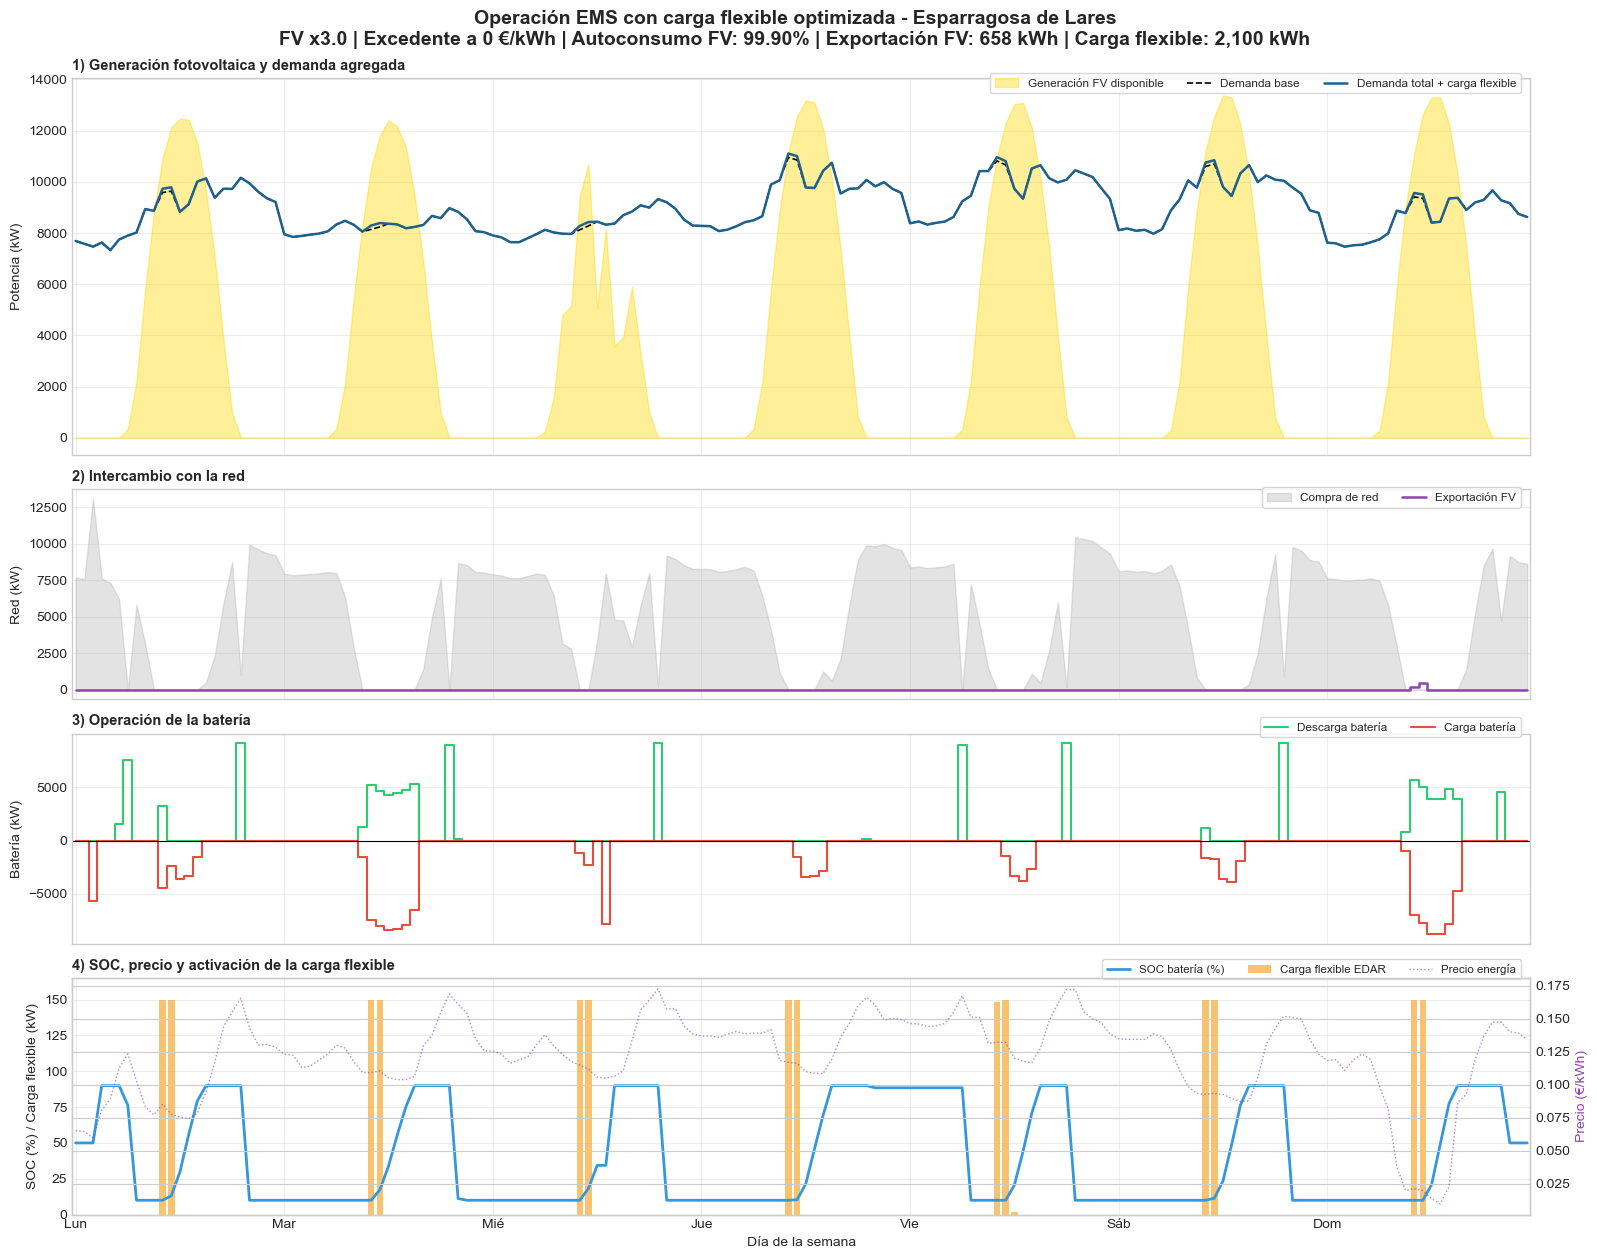

Archivo guardado: Balance_EMS_Flexible_Optimizado_Limpio.png


In [271]:
def guardar_grafico_ems_flexible_limpio(modelo, nombre_archivo="Balance_EMS_Flexible_Optimizado_Limpio.png"):
    plt.style.use('seaborn-v0_8-whitegrid')
    horas = np.arange(168)

    # 1. Extracción de datos
    factor_fv = pyo.value(modelo.pFactorFV)
    factor_venta = pyo.value(modelo.pFactorVentaExcedente)

    p_pv_total = (pyo.value(modelo.pSizePV_tejados)  + pyo.value(modelo.pSizePV_suelo)) * factor_fv

    solar = [p_pv_total * pyo.value(modelo.pFV[i]) for i in horas]
    demanda_base = [sum(pyo.value(modelo.pDemanda[i, c]) for c in modelo.sCons) for i in horas]
    flex = [pyo.value(modelo.vFlexLoad[i]) for i in horas]
    demanda_total = [demanda_base[i] + flex[i] for i in horas]

    compra = [sum(pyo.value(modelo.vXcompra[i, c]) for c in modelo.sCons) for i in horas]
    exportacion = [sum(pyo.value(modelo.vXventa[i, c]) for c in modelo.sCons) for i in horas]
    descarga = [sum(pyo.value(modelo.vXdescarga[i, c]) for c in modelo.sCons) for i in horas]
    carga = [sum(pyo.value(modelo.vXcarga[i, c]) for c in modelo.sCons) for i in horas]

    soc_perc = [(pyo.value(modelo.vSOC[i]) / pyo.value(modelo.pSizeESS)) * 100 for i in horas]
    precios = [pyo.value(modelo.pPrecioTotal[i]) for i in horas]

    # 2. KPIs rápidos para anotación
    total_compra = sum(compra)
    total_exportacion = sum(exportacion)
    total_flex = sum(flex)
    total_solar = sum(solar)
    autoconsumo_fv = total_solar - total_exportacion
    autoconsumo_pct = 100 * autoconsumo_fv / total_solar if total_solar > 0 else 0

    # Texto más claro para el tratamiento del excedente
    if abs(factor_venta) < 1e-9:
        texto_excedente = "Excedente a 0 €/kWh"
    else:
        texto_excedente = f"Excedente remunerado al {factor_venta:.1f}·Pool"

    # 3. Creación de figura
    fig, (ax1, ax2, ax3, ax4) = plt.subplots(
        4, 1,
        figsize=(16, 13.2),
        sharex=True,
        gridspec_kw={'height_ratios': [2.15, 1.2, 1.2, 1.35]}
    )

    fig.suptitle(
        'Operación EMS con carga flexible optimizada - Esparragosa de Lares\n'
        f'FV x{factor_fv:.1f} | {texto_excedente} | '
        f'Autoconsumo FV: {autoconsumo_pct:.2f}% | Exportación FV: {total_exportacion:,.0f} kWh | '
        f'Carga flexible: {total_flex:,.0f} kWh',
        fontsize=14,
        fontweight='bold',
        y=0.95
    )

    # PANEL 1: FV y demanda
    ax1.fill_between(horas, solar, label='Generación FV disponible', color='#FFD700', alpha=0.40)
    ax1.plot(horas, demanda_base, label='Demanda base', color='black', lw=1.2, linestyle='--')
    ax1.plot(horas, demanda_total, label='Demanda total + carga flexible', color='#1F618D', lw=1.8)

    ax1.set_ylabel('Potencia (kW)')
    ax1.set_title('1) Generación fotovoltaica y demanda agregada', fontsize=10.5, fontweight='bold', loc='left')

    ax1.legend(
        loc='upper right',
        bbox_to_anchor=(0.995, 1.02),
        ncol=3,
        fontsize=8.5,
        frameon=True,
        borderaxespad=0.2
    )

    # PANEL 2: Intercambio con red
    ax2.fill_between(horas, compra, label='Compra de red', color='#A9A9A9', alpha=0.32)
    ax2.step(horas, exportacion, where='mid', label='Exportación FV', color='#8E44AD', lw=1.8)

    ax2.set_ylabel('Red (kW)')
    ax2.set_title('2) Intercambio con la red', fontsize=10.5, fontweight='bold', loc='left')

    ax2.legend(
        loc='upper right',
        bbox_to_anchor=(0.995, 1.02),
        ncol=2,
        fontsize=8.5,
        frameon=True,
        borderaxespad=0.2
    )

    # PANEL 3: Batería
    ax3.step(horas, descarga, where='mid', label='Descarga batería', color='#2ECC71', lw=1.5)
    ax3.step(horas, [-x for x in carga], where='mid', label='Carga batería', color='#E74C3C', lw=1.5)
    ax3.axhline(0, color='black', lw=0.8)

    ax3.set_ylabel('Batería (kW)')
    ax3.set_title('3) Operación de la batería', fontsize=10.5, fontweight='bold', loc='left')

    ax3.legend(
        loc='upper right',
        bbox_to_anchor=(0.995, 1.09),
        ncol=2,
        fontsize=8.5,
        frameon=True,
        borderaxespad=0.2
    )

    # PANEL 4: SOC, precio y carga flexible
    ax4.plot(horas, soc_perc, color='#3498DB', label='SOC batería (%)', lw=2)
    ax4.bar(horas, flex, label='Carga flexible EDAR', color='#F39C12', alpha=0.60, width=0.75)

    ax4.set_ylabel('SOC (%) / Carga flexible (kW)')
    ax4.set_ylim(0, 165)
    ax4.set_title('4) SOC, precio y activación de la carga flexible', fontsize=10.5, fontweight='bold', loc='left')

    ax5 = ax4.twinx()
    ax5.plot(horas, precios, color='#8E44AD', label='Precio energía', lw=1, alpha=0.65, linestyle=':')
    ax5.set_ylabel('Precio (€/kWh)', color='#8E44AD')

    # Eje X
    ax4.set_xticks(np.arange(0, 169, 24))
    ax4.set_xticklabels(['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom', ''])
    ax4.set_xlabel('Día de la semana')

    # Leyenda combinada del panel 4, algo más arriba pero sin pegarla al título
    lines4, labels4 = ax4.get_legend_handles_labels()
    lines5, labels5 = ax5.get_legend_handles_labels()

    ax4.legend(
        lines4 + lines5,
        labels4 + labels5,
        loc='upper right',
        bbox_to_anchor=(0.995, 1.09),
        ncol=3,
        fontsize=8.3,
        frameon=True,
        borderaxespad=0.2
    )

    # Ajustes generales
    for ax in [ax1, ax2, ax3, ax4]:
        ax.grid(True, alpha=0.35)
        ax.margins(x=0)

    plt.tight_layout(rect=[0, 0, 1, 0.965])
    plt.savefig(nombre_archivo, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Archivo guardado: {nombre_archivo}")


guardar_grafico_ems_flexible_limpio(model_flex)

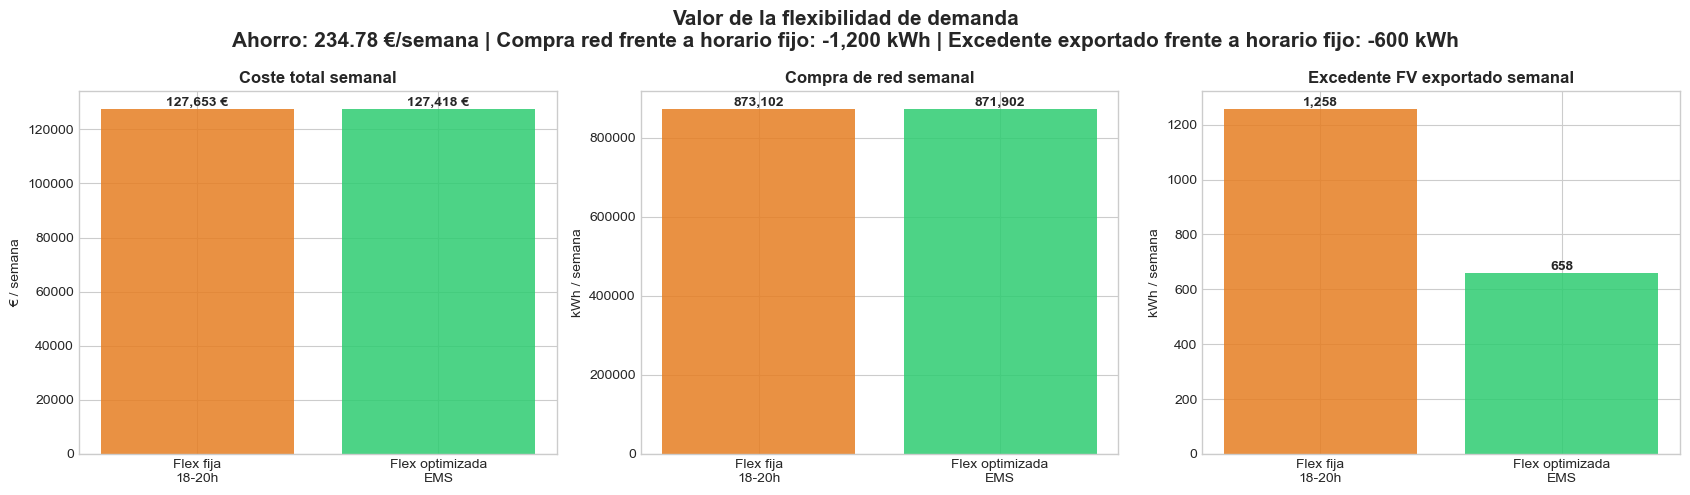

Archivo guardado: Comparacion_Flexibilidad_Fija_vs_Optimizada.png


In [272]:
def graficar_comparacion_flexibilidad(kpi_fijo, kpi_opt, nombre_archivo="Comparacion_Flexibilidad_Fija_vs_Optimizada.png"):
    plt.style.use('seaborn-v0_8-whitegrid')

    escenarios = ['Flex fija\n18-20h', 'Flex optimizada\nEMS']

    coste_total = [
        kpi_fijo["Coste total con inversión (€)"],
        kpi_opt["Coste total con inversión (€)"]
    ]

    compra_red = [
        kpi_fijo["Compra red (kWh)"],
        kpi_opt["Compra red (kWh)"]
    ]

    vertido = [
        kpi_fijo["Venta/vertido (kWh)"],
        kpi_opt["Venta/vertido (kWh)"]
    ]

    fig, axes = plt.subplots(1, 3, figsize=(17, 5))

    # Coste
    axes[0].bar(escenarios, coste_total, color=['#E67E22', '#2ECC71'], alpha=0.85)
    axes[0].set_title('Coste total semanal', fontweight='bold')
    axes[0].set_ylabel('€ / semana')
    for i, v in enumerate(coste_total):
        axes[0].text(i, v, f'{v:,.0f} €', ha='center', va='bottom', fontweight='bold')

    # Compra red
    axes[1].bar(escenarios, compra_red, color=['#E67E22', '#2ECC71'], alpha=0.85)
    axes[1].set_title('Compra de red semanal', fontweight='bold')
    axes[1].set_ylabel('kWh / semana')
    for i, v in enumerate(compra_red):
        axes[1].text(i, v, f'{v:,.0f}', ha='center', va='bottom', fontweight='bold')

    # Vertido
    axes[2].bar(escenarios, vertido, color=['#E67E22', '#2ECC71'], alpha=0.85)
    axes[2].set_title('Excedente FV exportado semanal', fontweight='bold')
    axes[2].set_ylabel('kWh / semana')
    for i, v in enumerate(vertido):
        axes[2].text(i, v, f'{v:,.0f}', ha='center', va='bottom', fontweight='bold')

    mejora_coste = coste_total[0] - coste_total[1]
    reduccion_compra = compra_red[0] - compra_red[1]
    reduccion_vertido = vertido[0] - vertido[1]

    fig.suptitle(
        f'Valor de la flexibilidad de demanda\n'
        f'Ahorro: {mejora_coste:,.2f} €/semana | '
        f'Compra red frente a horario fijo: -{reduccion_compra:,.0f} kWh | '
        f'Excedente exportado frente a horario fijo: -{reduccion_vertido:,.0f} kWh',
        fontsize=15, fontweight='bold'
    )

    plt.tight_layout()
    plt.savefig(nombre_archivo, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Archivo guardado: {nombre_archivo}")

graficar_comparacion_flexibilidad(kpi_flex_fijo, kpi_flex_opt)

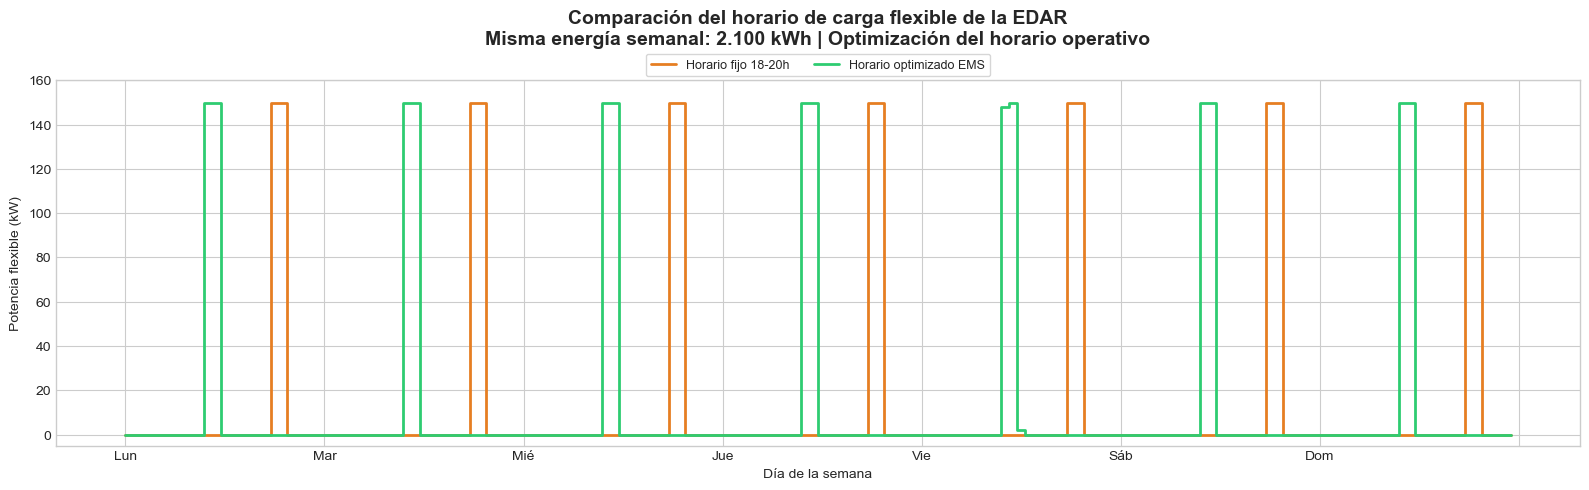

Archivo guardado: Horario_Carga_Flexible.png


In [273]:
def graficar_horario_carga_flexible(model_fijo, model_opt, nombre_archivo="Horario_Carga_Flexible.png"):
    plt.style.use('seaborn-v0_8-whitegrid')
    horas = np.arange(168)

    flex_fija = [pyo.value(model_fijo.vFlexLoad[i]) for i in horas]
    flex_opt = [pyo.value(model_opt.vFlexLoad[i]) for i in horas]

    fig, ax = plt.subplots(figsize=(16, 5.5))

    ax.step(horas, flex_fija, where='mid', label='Horario fijo 18-20h', color='#E67E22', lw=2)
    ax.step(horas, flex_opt, where='mid', label='Horario optimizado EMS', color='#2ECC71', lw=2)

    ax.set_title(
        'Comparación del horario de carga flexible de la EDAR\n'
        'Misma energía semanal: 2.100 kWh | Optimización del horario operativo',
        fontsize=14,
        fontweight='bold',
        pad=26
    )

    ax.set_ylabel('Potencia flexible (kW)')
    ax.set_xlabel('Día de la semana')

    ax.set_xticks(np.arange(0, 169, 24))
    ax.set_xticklabels(['Lun', 'Mar', 'Mié', 'Jue', 'Vie', 'Sáb', 'Dom', ''])

    ax.set_ylim(-5, 160)

    # Leyenda fuera del área del gráfico
    ax.legend(
        loc='upper center',
        bbox_to_anchor=(0.5, 1.09),
        ncol=2,
            frameon=True,
    fontsize=9
    )

    plt.tight_layout(rect=[0, 0, 1, 0.91])
    plt.savefig(nombre_archivo, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Archivo guardado: {nombre_archivo}")

graficar_horario_carga_flexible(model_flex_fijo, model_flex)